# ============================================================
# Boston Bluebikes — Descriptive Analysis: Demand & Imbalance Analysis

Research Objective: Establish a clean dataset and characterize where,
when, and how heavily Boston Bluebikes stations are used — covering
station-level demand, station imbalance, and year-over-year change
between 2019 and 2020. This section provides the descriptive
foundation that the second half of the notebook builds on.

1. Identify the busiest bike stations
2. Analyze monthly demand patterns and seasonality
3. Detect stations at risk of low bike availability
4. Examine spatial and temporal demand patterns
5. Compare demand patterns between 2019 and 2020
6. Assess consistency of station demand over time
7. Provide data-driven operational recommendations
# ============================================================

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

In [2]:
# Step 1: Load the Data
df_2019 = pd.read_csv("bluebikes_tripdata_2019.csv")
df_2020 = pd.read_csv("bluebikes_tripdata_2020.csv")

# Tag each year so we can compare them later
df_2019["year"] = 2019
df_2020["year"] = 2020

# Combine into one master dataframe
df = pd.concat([df_2019, df_2020], ignore_index=True)
 
print(f"Total records loaded: {len(df):,}")
print(df.head())

/var/folders/gk/km38nm795qs8nxlbs_58d1rm0000gn/T/ipykernel_70730/33937362.py:3: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  df_2020 = pd.read_csv("bluebikes_tripdata_2020.csv")


Total records loaded: 4,522,217
   tripduration                 starttime                  stoptime  \
0           790  2019-12-01 00:01:25.3240  2019-12-01 00:14:35.3350   
1           166  2019-12-01 00:05:42.8610  2019-12-01 00:08:29.3830   
2           323  2019-12-01 00:08:28.5560  2019-12-01 00:13:52.4340   
3           709  2019-12-01 00:08:38.5970  2019-12-01 00:20:27.6470   
4           332  2019-12-01 00:10:08.8160  2019-12-01 00:15:41.0510   

   start station id                       start station name  \
0               370               Dartmouth St at Newbury St   
1                80  MIT Stata Center at Vassar St / Main St   
2               381          Inman Square at Springfield St.   
3               185                          Third at Binney   
4               221    Verizon Innovation Hub 10 Ware Street   

   start station latitude  start station longitude  end station id  \
0               42.350961               -71.077828              33   
1               

In [3]:
# Step 2: Data Cleaning & Preparation

# 2a. Remove rows with missing critical fields
critical_cols = ["starttime", "start station name", "end station name"]
before = len(df)
df = df.dropna(subset=critical_cols)
print(f"Dropped {before - len(df):,} rows with missing values in critical columns.")

Dropped 0 rows with missing values in critical columns.


In [4]:
# 2b. Remove duplicate rows
df = df.drop_duplicates()
 
# 2c. Convert time columns to datetime
df["starttime"] = pd.to_datetime(df["starttime"], errors="coerce")
df["stoptime"]  = pd.to_datetime(df["stoptime"],  errors="coerce")

# Drop rows where datetime parsing failed
df = df.dropna(subset=["starttime"])

In [5]:
# 2d. Extract useful time features
df["month"]      = df["starttime"].dt.month          # 1-12
df["month_name"] = df["starttime"].dt.strftime("%b") # Jan, Feb, ...Dec
df["date"]       = df["starttime"].dt.date
 
# Keep an unfiltered copy for anomaly detection in Insight 9
# (the filter below removes the very trips Insight 9 needs to identify)
df_raw = df.copy()
 
# 2e. Remove trips with implausible durations
# Reasonable Trip Durations: Keep only trips between 1 minute and 24 hours
if "tripduration" in df.columns:
    df = df[(df["tripduration"] >= 60) & (df["tripduration"] <= 86400)]
 
print(f"\nClean dataset shape: {df.shape}")
print(f"Raw dataset shape (kept for Insight 9): {df_raw.shape}")
print(df[["starttime", "month", "year", "start station name"]].head())



Clean dataset shape: (4517644, 20)
Raw dataset shape (kept for Insight 9): (4522217, 20)
                starttime  month  year  \
0 2019-12-01 00:01:25.324     12  2019   
1 2019-12-01 00:05:42.861     12  2019   
2 2019-12-01 00:08:28.556     12  2019   
3 2019-12-01 00:08:38.597     12  2019   
4 2019-12-01 00:10:08.816     12  2019   

                        start station name  
0               Dartmouth St at Newbury St  
1  MIT Stata Center at Vassar St / Main St  
2          Inman Square at Springfield St.  
3                          Third at Binney  
4    Verizon Innovation Hub 10 Ware Street  


In [6]:
# 2f. Tag each station with a location type (university, transit hub, etc.)
# Used by Insight 13 academic-calendar dampening, and available for any insight
# that wants to break out by station context. Patterns are name-based and can be
# refined; unmatched stations fall through to 'residential_other'.
import re

def classify_station(name):
    n = str(name).lower()
    if re.search(r'\b(mit|harvard|boston university|\bbu\b|northeastern|tufts|emerson|simmons|wentworth|berklee|suffolk)\b', n):
        return 'university'
    if re.search(r'\b(kendall|vassar|stata|ames st|broadway|cambridgeport)\b', n):
        return 'university_adjacent'
    if re.search(r'\b(south station|north station|back bay station|copley|park st|government ctr|state st|t stop|ruggles)\b', n):
        return 'transit_hub'
    if re.search(r'\b(financial|downtown|federal|congress st|post office sq|dewey sq)\b', n):
        return 'business_district'
    if re.search(r'\b(esplanade|beacon st|charles|boston common|public garden|fenway|kenmore|seaport|fan pier|waterfront)\b', n):
        return 'leisure_waterfront'
    return 'residential_other'

df['station_type']     = df['start station name'].apply(classify_station)
df_raw['station_type'] = df_raw['start station name'].apply(classify_station)

print('Station counts by type:')
print(df.groupby('station_type')['start station name'].nunique().sort_values(ascending=False))

# Optional follow-ons (uncomment if you want type-segmented breakouts):
# print('\nTrips by station_type and year:')
# print(df.groupby(['station_type', 'year']).size().unstack(fill_value=0))
# print('\nWeekday vs Weekend share by station_type:')
# print(df.groupby(['station_type', 'week_type']).size().unstack(fill_value=0).apply(lambda r: r / r.sum(), axis=1))


Station counts by type:
station_type
residential_other      304
leisure_waterfront      25
transit_hub             25
university              25
university_adjacent     25
business_district        5
Name: start station name, dtype: int64


In [7]:
# Step 3: Exploratory Data Analysis

# 3a. Overall trip counts by year
trip_counts = df.groupby("year").size().reset_index(name="total_trips")
print("\nTrips by Year:")
print(trip_counts)


Trips by Year:
   year  total_trips
0  2019      2520381
1  2020      1997263



Monthly Trip Volume (sample):
    year  month month_name  trip_count
0   2019      1        Jan       69815
1   2019      2        Feb       80380
2   2019      3        Mar      102242
3   2019      4        Apr      166516
4   2019      5        May      222828
5   2019      6        Jun      273729
6   2019      7        Jul      316682
7   2019      8        Aug      337167
8   2019      9        Sep      362944
9   2019     10        Oct      305325
10  2019     11        Nov      190634
11  2019     12        Dec       92119


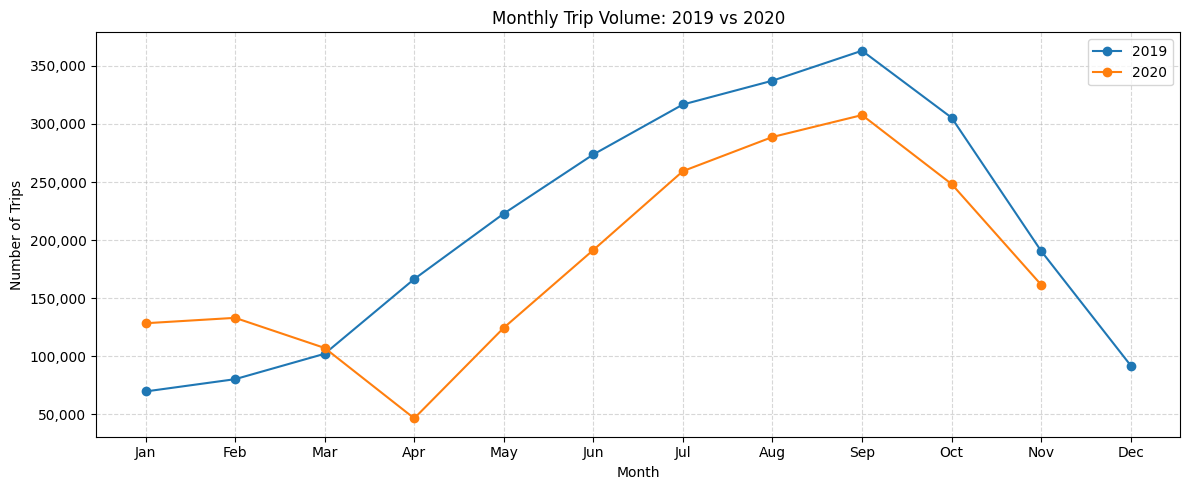

Saved: monthly_trend.png


In [8]:
# 3b. Monthly trip volume (both years combined)
monthly_trips = (
    df.groupby(["year", "month", "month_name"])
    .size()
    .reset_index(name="trip_count")
    .sort_values(["year", "month"])
)
print("\nMonthly Trip Volume (sample):")
print(monthly_trips.head(12))
 
# 3c. Plot monthly trip trends side-by-side
fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp in monthly_trips.groupby("year"):
    ax.plot(grp["month"], grp["trip_count"], marker="o", label=str(yr))
 
ax.set_title("Monthly Trip Volume: 2019 vs 2020")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Trips")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("monthly_trend.png", dpi=150)
plt.show()
print("Saved: monthly_trend.png")

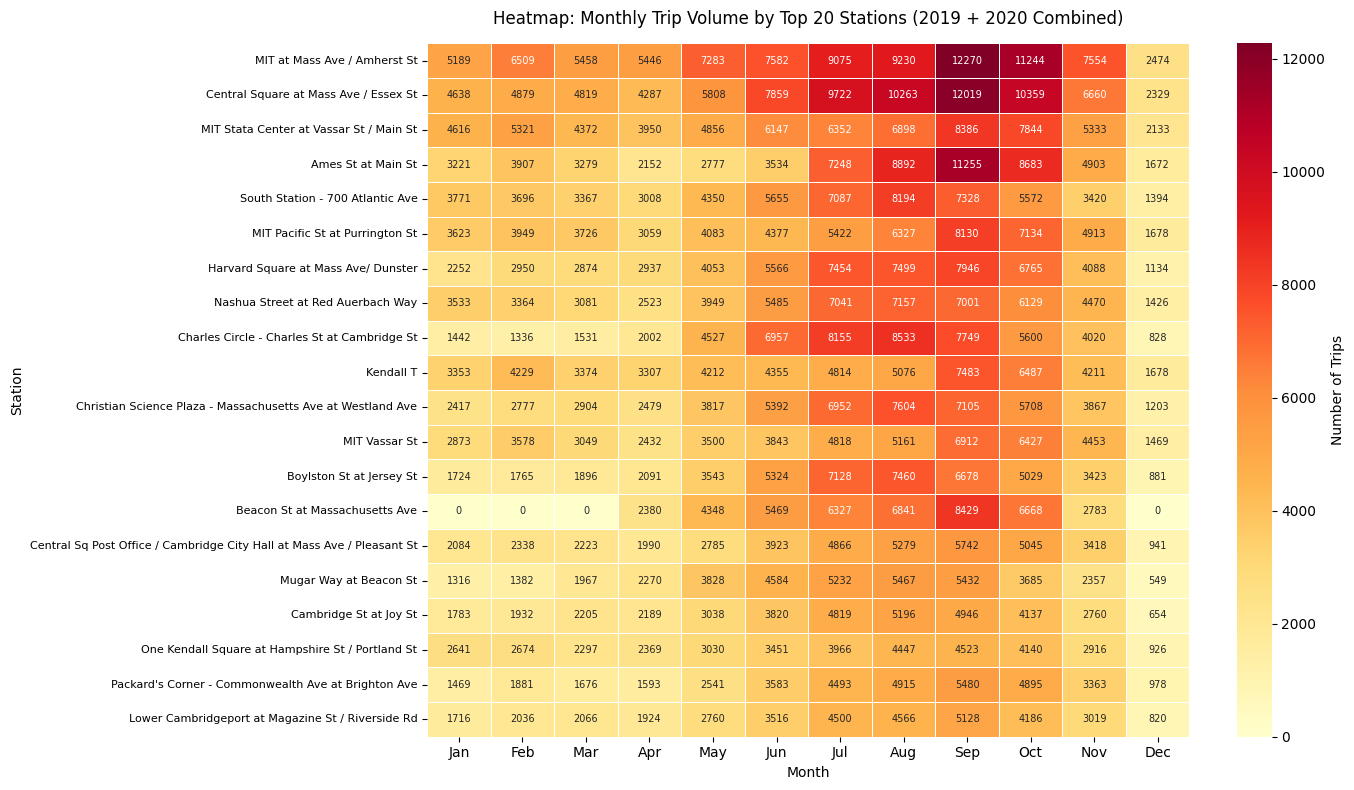

Saved: heatmap_station_month.png


In [9]:
# 3d. Heatmap 1: Trip Volume by Station × Month (Top 20 Stations)
# Identify top 20 stations by total departures
top20_stations = (
    df.groupby("start station name")
    .size()
    .nlargest(20)
    .index.tolist()
)
 
# Build a pivot: rows = station, columns = month
station_month = (
    df[df["start station name"].isin(top20_stations)]
    .groupby(["start station name", "month"])
    .size()
    .reset_index(name="trips")
)
heatmap_data = station_month.pivot(
    index="start station name", columns="month", values="trips"
).fillna(0)
heatmap_data.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                         "Jul","Aug","Sep","Oct","Nov","Dec"]
# Sort rows by total trips descending
heatmap_data = heatmap_data.loc[heatmap_data.sum(axis=1).sort_values(ascending=False).index]
 
fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    linewidths=0.4,
    annot=True,
    fmt=".0f",
    annot_kws={"size": 7},
    cbar_kws={"label": "Number of Trips"},
    ax=ax
)
ax.set_title("Heatmap: Monthly Trip Volume by Top 20 Stations (2019 + 2020 Combined)", pad=14)
ax.set_xlabel("Month")
ax.set_ylabel("Station")
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.savefig("heatmap_station_month.png", dpi=150)
plt.show()
print("Saved: heatmap_station_month.png")

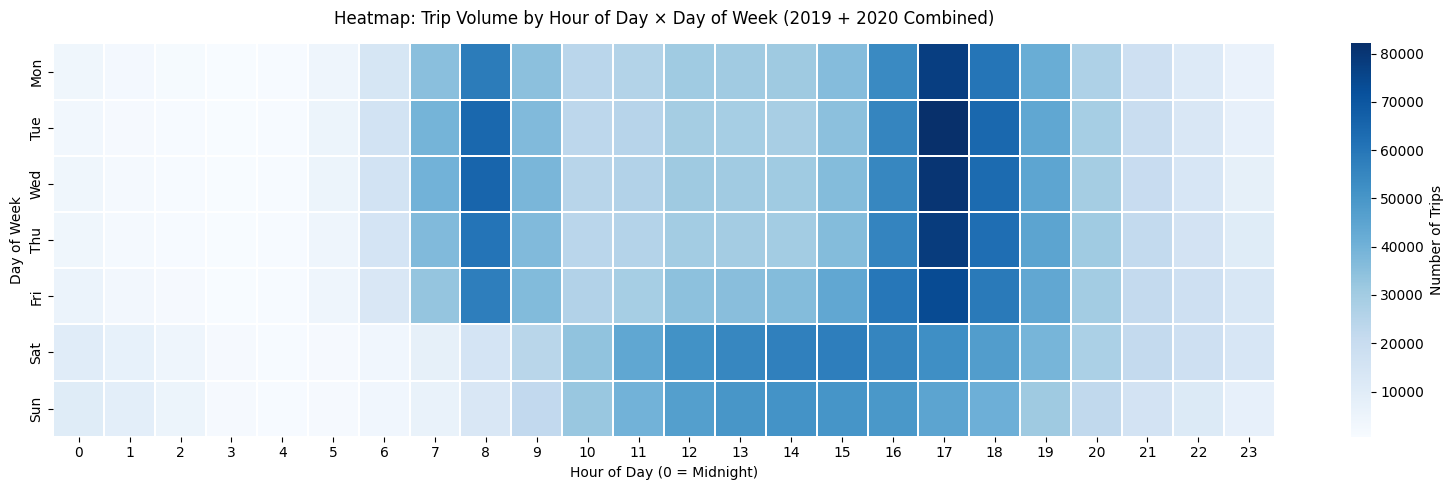

Saved: heatmap_hour_dow.png


In [29]:
# 3e. Heatmap 2: Trip Volume by Hour × Day of Week
df["hour"]      = df["starttime"].dt.hour
df["dayofweek"] = df["starttime"].dt.dayofweek   # 0=Monday … 6=Sunday
 
hour_dow = (
    df.groupby(["dayofweek", "hour"])
    .size()
    .reset_index(name="trips")
)
heatmap_dow = hour_dow.pivot(index="dayofweek", columns="hour", values="trips").fillna(0)
heatmap_dow.index = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
 
fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    heatmap_dow,
    cmap="Blues",
    linewidths=0.3,
    annot=False,
    cbar_kws={"label": "Number of Trips"},
    ax=ax
)
ax.set_title("Heatmap: Trip Volume by Hour of Day × Day of Week (2019 + 2020 Combined)", pad=14)
ax.set_xlabel("Hour of Day (0 = Midnight)")
ax.set_ylabel("Day of Week")
plt.tight_layout()
plt.savefig("heatmap_hour_dow.png", dpi=150)
plt.show()
print("Saved: heatmap_hour_dow.png")

In [10]:
#Step 4: Station Demand Analysis

# 4a. Count departures per station
departures = (
    df.groupby("start station name")
    .size()
    .reset_index(name="departures")
    .sort_values("departures", ascending=False)
)

print("\nTop 10 Stations by Departures:")
print(departures.head(10))


Top 10 Stations by Departures:
                              start station name  departures
240                 MIT at Mass Ave / Amherst St       89314
95         Central Square at Mass Ave / Essex St       83642
238      MIT Stata Center at Vassar St / Main St       66208
22                            Ames St at Main St       61523
335             South Station - 700 Atlantic Ave       56842
237              MIT Pacific St at Purrington St       56421
193          Harvard Square at Mass Ave/ Dunster       55518
273            Nashua Street at Red Auerbach Way       55159
100  Charles Circle - Charles St at Cambridge St       52680
221                                    Kendall T       52579


In [11]:
# 4b. Count arrivals per station
arrivals = (
    df.groupby("end station name")
    .size()
    .reset_index(name="arrivals")
    .rename(columns={"end station name": "start station name"})
)

print("\nTop 10 Stations by Arrivals:")
print(arrivals.head(10))



Top 10 Stations by Arrivals:
                          start station name  arrivals
0                           175 N Harvard St     22647
1                      18 Dorrance Warehouse       958
2                              191 Beacon St     10347
3                                 30 Dane St     14419
4                                30 Dane St.       310
5  359 Broadway - Broadway at Fayette Street     22894
6                              645 Summer St       113
7                           699 Mt Auburn St      7442
8                                7 Acre Park      1445
9                      700 Commonwealth Ave.     10336


In [18]:
# 4c. Merge departures and arrivals into one station table for easy viewing
# Assuming that "Busier" means more departures; we will rank by departures but also show arrivals and total trips.

station_demand = departures.merge(arrivals, on="start station name", how="outer").fillna(0)
station_demand.columns = ["station", "departures", "arrivals"]
station_demand["total_trips"] = station_demand["departures"] + station_demand["arrivals"]
station_demand = station_demand.sort_values("total_trips", ascending=False).reset_index(drop=True)
station_demand["rank"] = station_demand.index + 1
 
print("\nTop 10 Busiest Stations")
print(station_demand.head(10).to_string(index=False))


Top 10 Busiest Stations
                                                    station  departures  arrivals  total_trips  rank
                               MIT at Mass Ave / Amherst St     89314.0   83523.0     172837.0     1
                      Central Square at Mass Ave / Essex St     83642.0   84914.0     168556.0     2
                                         Ames St at Main St     61523.0   72400.0     133923.0     3
                    MIT Stata Center at Vassar St / Main St     66208.0   58512.0     124720.0     4
                          Nashua Street at Red Auerbach Way     55159.0   67168.0     122327.0     5
                        Harvard Square at Mass Ave/ Dunster     55518.0   57885.0     113403.0     6
                           South Station - 700 Atlantic Ave     56842.0   53507.0     110349.0     7
                            MIT Pacific St at Purrington St     56421.0   53225.0     109646.0     8
                Charles Circle - Charles St at Cambridge St     52

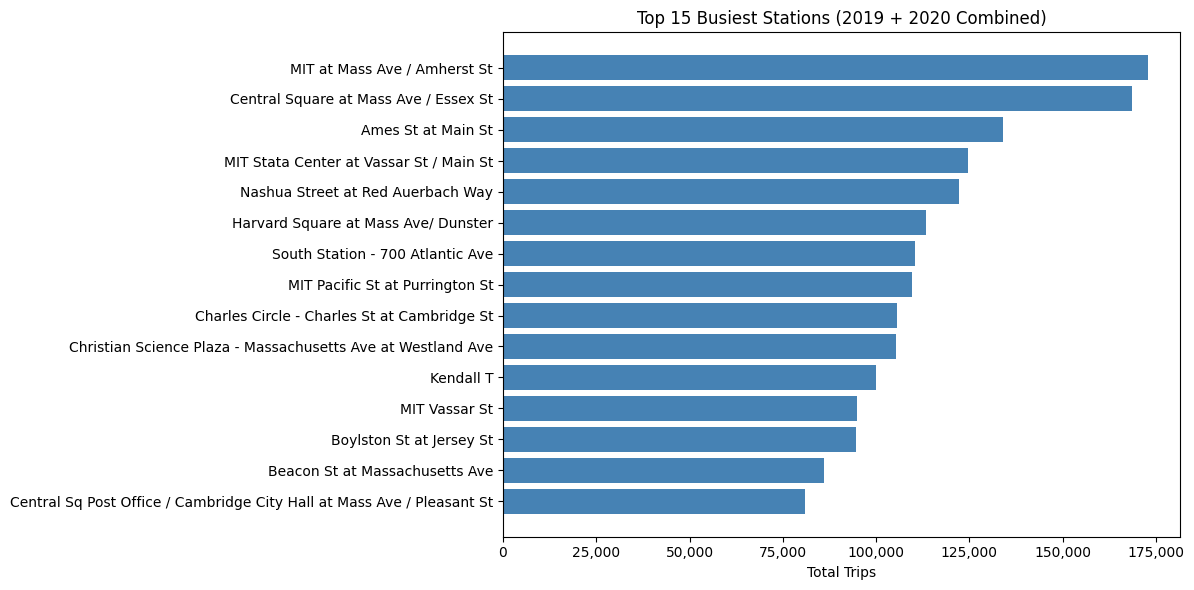

Saved: top15_stations.png


In [14]:
# 4d. Plot top 15 stations by total trips
top15 = station_demand.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top15["station"][::-1], top15["total_trips"][::-1], color="steelblue")
ax.set_title("Top 15 Busiest Stations (2019 + 2020 Combined)")
ax.set_xlabel("Total Trips")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("top15_stations.png", dpi=150)
plt.show()
print("Saved: top15_stations.png")

In [20]:
# Step 5: Imbalance & Bike Availability Analysis
# (reuses departures / arrivals / station_demand computed in Step 4)

# Net Flow = Arrivals - Departures
# Net Flow Positive --> More bikes arriving than departing (potentially too many bikes)
# Net Flow Negative --> More bikes departing than arriving (potentially not enough bikes)

station_demand["net_flow"] = station_demand["arrivals"] - station_demand["departures"]

# 5a. Stations most at risk of running out of bikes
at_risk = station_demand.sort_values("net_flow").head(15)
 
# 5b. Stations with surplus accumulation
surplus = station_demand.sort_values("net_flow", ascending=False).head(15)
 
print("\nStations Most at Risk of Low Bike Availability (most negative net flow):")
print(at_risk[["station", "departures", "arrivals", "net_flow"]].to_string(index=False))
 
print("\nStations with Bike Surplus (most positive net flow):")
print(surplus[["station", "departures", "arrivals", "net_flow"]].to_string(index=False))


Stations Most at Risk of Low Bike Availability (most negative net flow):
                                         station  departures  arrivals  net_flow
         MIT Stata Center at Vassar St / Main St     66208.0   58512.0   -7696.0
                    MIT at Mass Ave / Amherst St     89314.0   83523.0   -5791.0
                                       Kendall T     52579.0   47387.0   -5192.0
    Government Center - Cambridge St at Court St     20627.0   16866.0   -3761.0
                South Station - 700 Atlantic Ave     56842.0   53507.0   -3335.0
       359 Broadway - Broadway at Fayette Street     26183.0   22894.0   -3289.0
                 MIT Pacific St at Purrington St     56421.0   53225.0   -3196.0
                  Community Path at Cedar Street     13602.0   10860.0   -2742.0
                    Washington St at Egremont Rd      7297.0    4705.0   -2592.0
                         Warren St at Chelsea St     26825.0   24272.0   -2553.0
                            Somervi

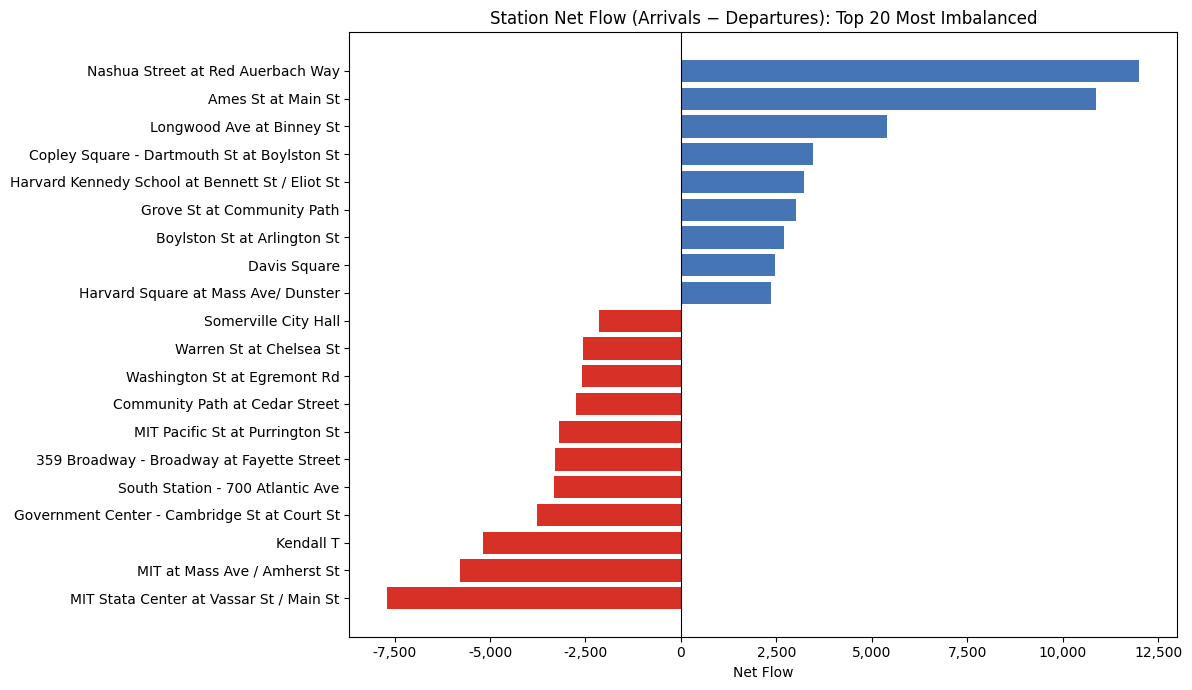

Saved: net_flow_imbalance.png


In [21]:
# 5c. Visualize net flow for top 20 imbalanced stations
imbalanced = station_demand.reindex(
    station_demand["net_flow"].abs().nlargest(20).index
).sort_values("net_flow")
 
colors = ["#d73027" if v < 0 else "#4575b4" for v in imbalanced["net_flow"]]
fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(imbalanced["station"], imbalanced["net_flow"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Station Net Flow (Arrivals − Departures): Top 20 Most Imbalanced")
ax.set_xlabel("Net Flow")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig("net_flow_imbalance.png", dpi=150)
plt.show()
print("Saved: net_flow_imbalance.png")

In [22]:
# Step 6: Year Over Year Comparison (2019 vs 2020)

# 6a. Departures per station per year
station_year = (
    df.groupby(["start station name", "year"])
    .size()
    .reset_index(name="departures")
)
 
pivot_yoy = station_year.pivot(
    index="start station name", columns="year", values="departures"
).fillna(0)
pivot_yoy.columns = ["trips_2019", "trips_2020"]
pivot_yoy["change"]    = pivot_yoy["trips_2020"] - pivot_yoy["trips_2019"]
pivot_yoy["pct_change"] = (pivot_yoy["change"] / pivot_yoy["trips_2019"].replace(0, pd.NA)) * 100
pivot_yoy = pivot_yoy.sort_values("change", ascending=False).reset_index()
 
print("\nTop 10 Stations with Biggest Growth (2019 → 2020):")
print(pivot_yoy.head(10)[["start station name", "trips_2019", "trips_2020", "change", "pct_change"]].to_string(index=False))
 
print("\nTop 10 Stations with Biggest Decline (2019 → 2020):")
print(pivot_yoy.tail(10)[["start station name", "trips_2019", "trips_2020", "change", "pct_change"]].to_string(index=False))


Top 10 Stations with Biggest Growth (2019 → 2020):
                         start station name  trips_2019  trips_2020  change  pct_change
 Landmark Center - Brookline Ave at Park Dr         0.0     14355.0 14355.0        <NA>
                     Cross St at Hanover St      7281.0     21439.0 14158.0  194.451312
Charles Circle - Charles St at Cambridge St     20988.0     31692.0 10704.0   51.000572
       Berkshire Street at Cambridge Street      3462.0     10953.0  7491.0  216.377816
              Commonwealth Ave at Griggs St      3476.0     10345.0  6869.0  197.612198
                      700 Commonwealth Ave.      1577.0      8349.0  6772.0  429.422955
            Congress St at Boston City Hall       539.0      6074.0  5535.0  1026.90167
                   Blossom St at Charles St      2849.0      8363.0  5514.0  193.541594
    Kennedy-Longfellow School 158 Spring St      4512.0      9629.0  5117.0  113.408688
               Columbus Ave at W. Canton St      2676.0      7355.0 

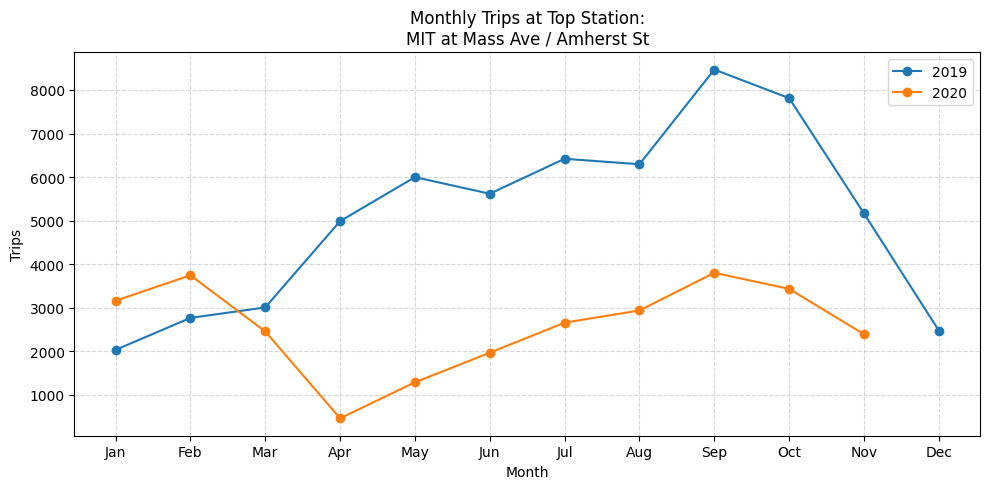

Saved: top_station_monthly_yoy.png


In [23]:
# 6b. Monthly comparison plot for busiest station
top_station = station_demand.iloc[0]["station"]
 
monthly_top = (
    df[df["start station name"] == top_station]
    .groupby(["year", "month"])
    .size()
    .reset_index(name="trips")
    .sort_values(["year", "month"])
)
 
fig, ax = plt.subplots(figsize=(10, 5))
for yr, grp in monthly_top.groupby("year"):
    ax.plot(grp["month"], grp["trips"], marker="o", label=str(yr))
 
ax.set_title(f"Monthly Trips at Top Station:\n{top_station}")
ax.set_xlabel("Month")
ax.set_ylabel("Trips")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("top_station_monthly_yoy.png", dpi=150)
plt.show()
print("Saved: top_station_monthly_yoy.png")

In [26]:
# Step 7: Export Summary Results

# Save key tables to CSV for reporting
station_demand.to_csv("station_demand_summary.csv", index=False)
pivot_yoy.to_csv("station_yoy_comparison.csv", index=False)
monthly_trips.to_csv("monthly_trips.csv", index=False)
 
print("\nAll summary CSVs saved")



All summary CSVs saved


# ============================================================
# Boston Bluebikes — Additional Insights: Rider Behavior, Operations & Capacity Planning

Research Objective: Build on the descriptive analysis above to
understand rider behavior, identify operational opportunities
(maintenance windows, fleet sizing), and recommend an optimal
per-station bike allocation under demand uncertainty.

1.  Analyze trip duration patterns across stations and time periods
2.  Compare usage behavior between Subscribers and Customers
3.  Identify differences in riding patterns (e.g., commuting vs leisure)
4.  Examine popular routes and origin-destination patterns
5.  Detect one-way dominant routes that contribute to system imbalance
6.  Assess overall system efficiency and usage distribution
7.  Generate insights to support operational improvements
8.  Forecast 2021 station-level demand using Simple Exponential Smoothing
9.  Optimize per-station bike allocation under demand uncertainty using the Newsvendor model
10. Translate optimal stock levels into a fleet-wide bike allocation across critical service ratios
# ============================================================

In [30]:
# Add extra time features needed for the insights below
# (df is already loaded, cleaned, and merged from the analysis above)
df["day_name"]  = df["starttime"].dt.strftime("%a")   # Mon, Tue, ...
df["week_type"] = df["dayofweek"].apply(lambda x: "Weekend" if x >= 5 else "Weekday")

# Trip duration in minutes
if "tripduration" in df.columns:
    df["duration_min"] = df["tripduration"] / 60
else:
    df["duration_min"] = (df["stoptime"] - df["starttime"]).dt.total_seconds() / 60

# Output directory for insight charts/CSVs
OUT_DIR = ""

print(f"Data ready for insights: {len(df):,} total trips")


Data ready for insights: 4,517,644 total trips


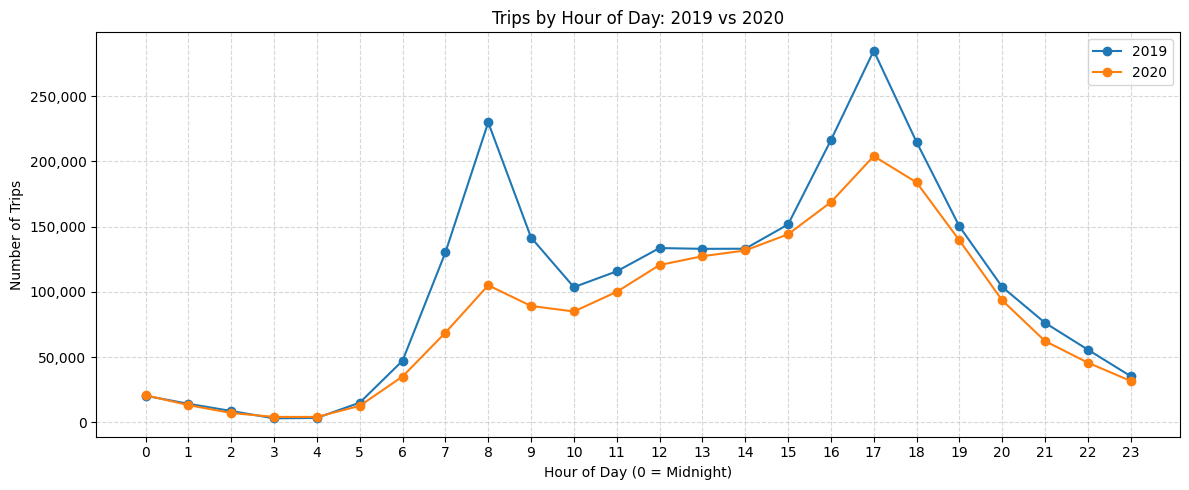

Saved: insight1_time_of_day.png


In [31]:
# INSIGHT 1: Time-of-Day Analysis

hourly = df.groupby(["year", "hour"]).size().reset_index(name="trips")
 
fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp in hourly.groupby("year"):
    ax.plot(grp["hour"], grp["trips"], marker="o", label=str(yr))
 
ax.set_title("Trips by Hour of Day: 2019 vs 2020")
ax.set_xlabel("Hour of Day (0 = Midnight)")
ax.set_ylabel("Number of Trips")
ax.set_xticks(range(0, 24))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR + "insight1_time_of_day.png", dpi=150)
plt.show()
print("Saved: insight1_time_of_day.png")

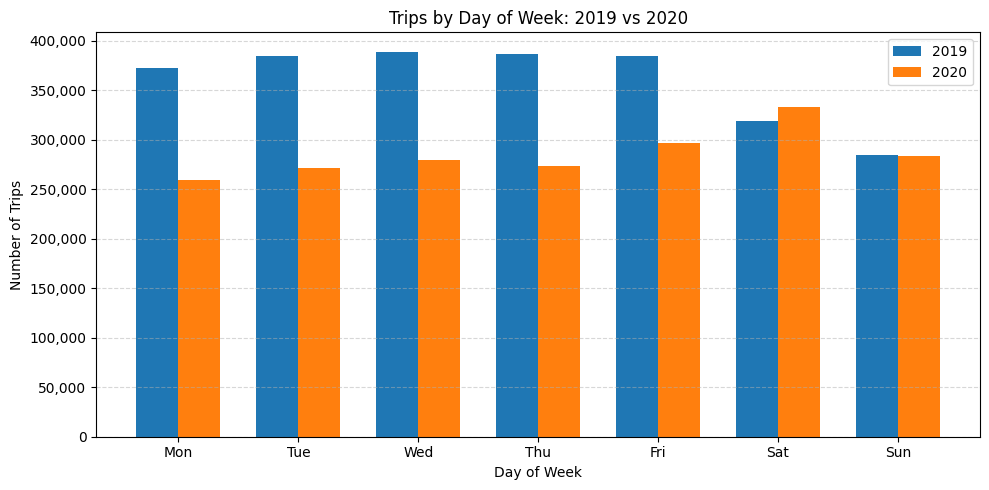

Saved: insight2_day_of_week.png


In [32]:
# INSIGHT 2: Day-of-Week Breakdown

dow_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow_trips = df.groupby(["year", "day_name"]).size().reset_index(name="trips")
dow_trips["day_name"] = pd.Categorical(dow_trips["day_name"], categories=dow_order, ordered=True)
dow_trips = dow_trips.sort_values(["year", "day_name"])
 
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.35
days = dow_order
x = range(len(days))
 
for i, (yr, grp) in enumerate(dow_trips.groupby("year")):
    grp = grp.set_index("day_name").reindex(days)
    ax.bar([p + i * width for p in x], grp["trips"], width=width, label=str(yr))
 
ax.set_title("Trips by Day of Week: 2019 vs 2020")
ax.set_xlabel("Day of Week")
ax.set_ylabel("Number of Trips")
ax.set_xticks([p + width / 2 for p in x])
ax.set_xticklabels(days)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR + "insight2_day_of_week.png", dpi=150)
plt.show()
print("Saved: insight2_day_of_week.png")

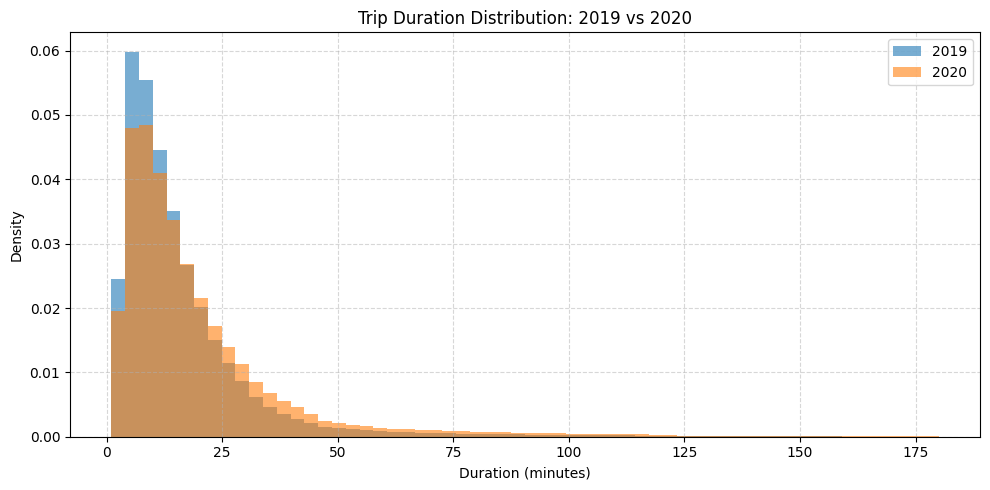


Median Trip Duration (minutes):
year
2019    11.750000
2020    13.816667
Saved: insight3_trip_duration.png


In [33]:
# INSIGHT 3: Trip Duration Distribution

# Filter to reasonable durations (1 min – 3 hours)
dur = df[(df["duration_min"] >= 1) & (df["duration_min"] <= 180)]
 
fig, ax = plt.subplots(figsize=(10, 5))
for yr, grp in dur.groupby("year"):
    ax.hist(grp["duration_min"], bins=60, alpha=0.6, label=str(yr), density=True)
 
ax.set_title("Trip Duration Distribution: 2019 vs 2020")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR + "insight3_trip_duration.png", dpi=150)
plt.show()
 
median_dur = dur.groupby("year")["duration_min"].median()
print("\nMedian Trip Duration (minutes):")
print(median_dur.to_string())
print("Saved: insight3_trip_duration.png")


Round Trip Rate (%):
year
2019    3.533037
2020    8.064787


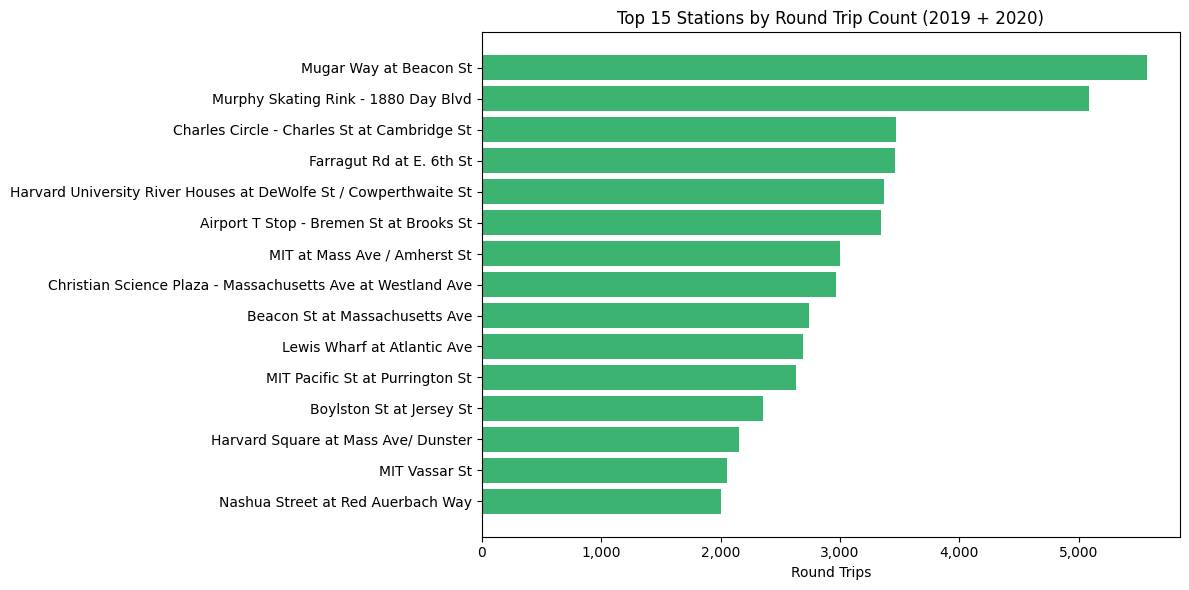

Saved: insight4_round_trips.png


In [35]:
# INSIGHT 4: Round Trips (Same Start & End Station)

df["is_round_trip"] = df["start station name"] == df["end station name"]
round_trip_rate = df.groupby("year")["is_round_trip"].mean() * 100
 
print("\nRound Trip Rate (%):")
print(round_trip_rate.to_string())
 
# Top round-trip stations
top_round = (
    df[df["is_round_trip"]]
    .groupby("start station name")
    .size()
    .reset_index(name="round_trips")
    .sort_values("round_trips", ascending=False)
    .head(15)
)
 
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_round["start station name"][::-1], top_round["round_trips"][::-1], color="mediumseagreen")
ax.set_title("Top 15 Stations by Round Trip Count (2019 + 2020)")
ax.set_xlabel("Round Trips")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(OUT_DIR + "insight4_round_trips.png", dpi=150)
plt.show()
print("Saved: insight4_round_trips.png")

In [36]:
# 4b: Round trip rate by user type (extends the by-year rate already printed above)
rt_by_user = df.groupby(["year", "usertype"])["is_round_trip"].mean() * 100
print("Round Trip Rate by User Type:")
for (yr, ut), rate in rt_by_user.items():
    print(f"  {yr} {ut:>12}: {rate:.2f}%")


Round Trip Rate by User Type:
  2019     Customer: 9.83%
  2019   Subscriber: 1.85%
  2020     Customer: 17.65%
  2020   Subscriber: 4.36%


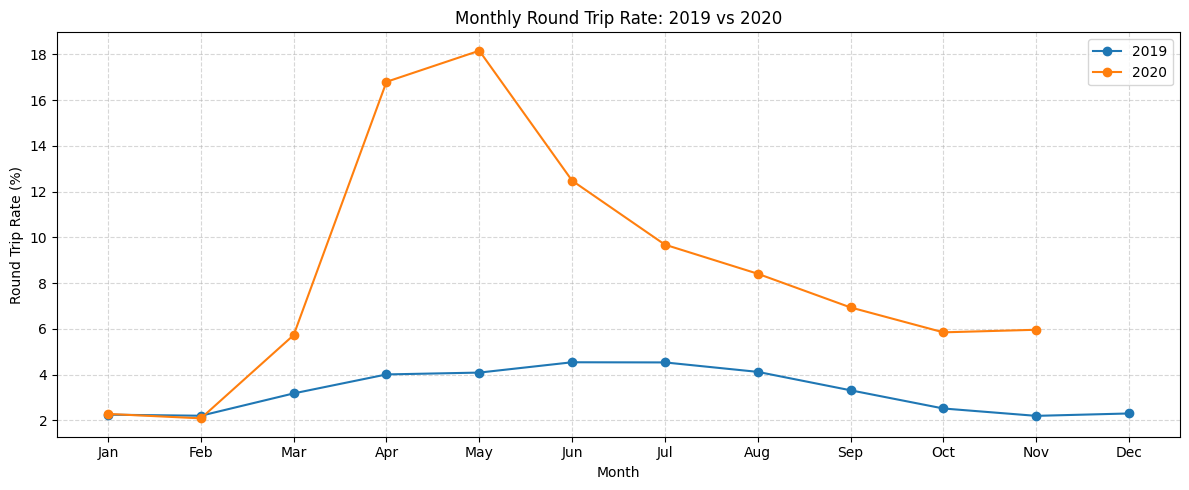

Saved: insight4b_round_trip_rate_monthly.png


In [37]:
# 4c: Monthly round trip rate trend (2019 vs 2020)
rt_monthly = df.groupby(["year", "month"])["is_round_trip"].mean().reset_index(name="rt_rate")
rt_monthly["rt_rate"] *= 100

fig, ax = plt.subplots(figsize=(12, 5))
for yr, grp in rt_monthly.groupby("year"):
    ax.plot(grp["month"], grp["rt_rate"], marker="o", label=str(yr))

ax.set_title("Monthly Round Trip Rate: 2019 vs 2020")
ax.set_xlabel("Month")
ax.set_ylabel("Round Trip Rate (%)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR + "insight4b_round_trip_rate_monthly.png", dpi=150)
plt.show()
print("Saved: insight4b_round_trip_rate_monthly.png")



Top 15 Most Popular Station Pairs:
                                                                  trip_pair  trips
                     MIT Pacific St at Purrington St  →  Ames St at Main St   7137
MIT Pacific St at Purrington St  →  MIT Stata Center at Vassar St / Main St   6933
MIT Stata Center at Vassar St / Main St  →  MIT Pacific St at Purrington St   6843
                             MIT at Mass Ave / Amherst St  →  MIT Vassar St   6351
                                       MIT Vassar St  →  Ames St at Main St   6184
  Central Square at Mass Ave / Essex St  →  MIT Pacific St at Purrington St   6108
                             MIT Vassar St  →  MIT at Mass Ave / Amherst St   5495
     MIT at Mass Ave / Amherst St  →  Central Square at Mass Ave / Essex St   5458
                  MIT Vassar St  →  MIT Stata Center at Vassar St / Main St   5405
              Community Path at Cedar Street  →  Grove St at Community Path   5229
                  MIT Stata Center at Vassar St / M

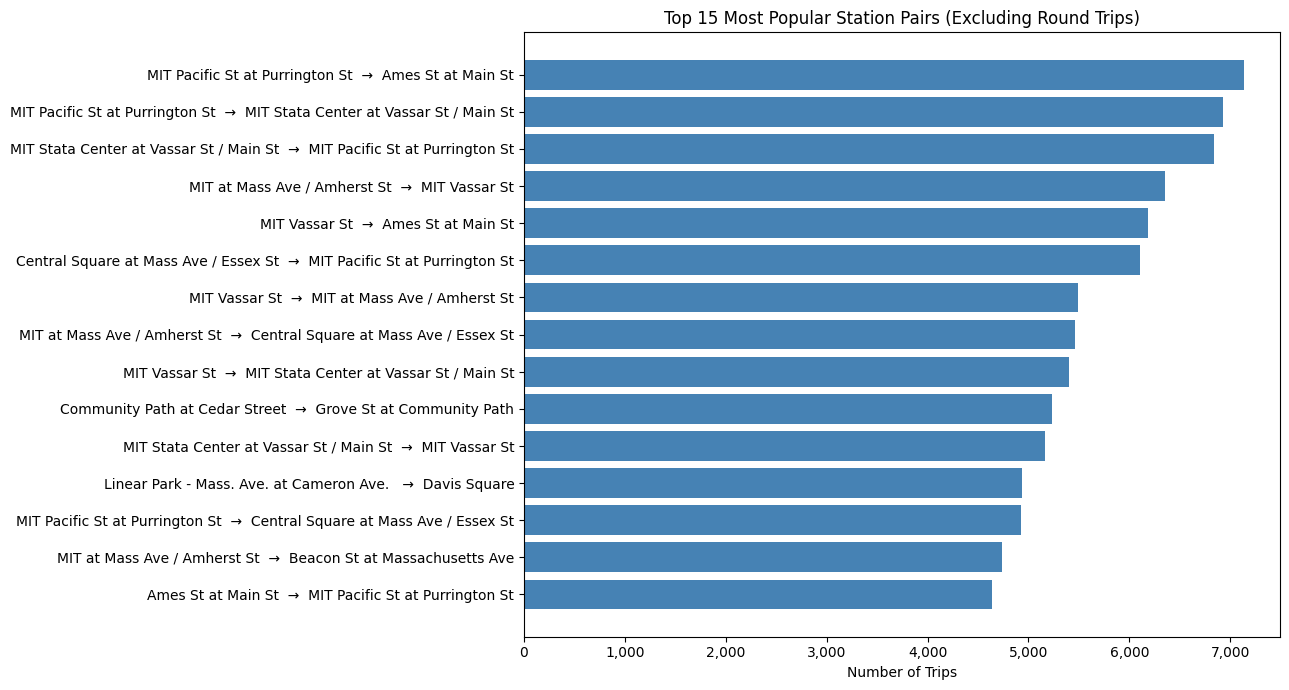

Saved: insight5_station_pairs.png


In [38]:
# INSIGHT 5: Most Popular Station Pairs (Origin → Destination)

df["trip_pair"] = df["start station name"] + "  →  " + df["end station name"]
 
# Exclude round trips for cleaner results
top_pairs = (
    df[~df["is_round_trip"]]
    .groupby("trip_pair")
    .size()
    .reset_index(name="trips")
    .sort_values("trips", ascending=False)
    .head(15)
)
 
print("\nTop 15 Most Popular Station Pairs:")
print(top_pairs.to_string(index=False))
 
fig, ax = plt.subplots(figsize=(13, 7))
ax.barh(top_pairs["trip_pair"][::-1], top_pairs["trips"][::-1], color="steelblue")
ax.set_title("Top 15 Most Popular Station Pairs (Excluding Round Trips)")
ax.set_xlabel("Number of Trips")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(OUT_DIR + "insight5_station_pairs.png", dpi=150)
plt.show()
print("Saved: insight5_station_pairs.png")

In [43]:
# INSIGHT 5b: Top Routes by Hour - Animated Map (Plotly) - Extends Insight 5 (static top pairs) with a geographic, hour-by-hour view of the most popular routes.
import plotly.graph_objects as go

# Work on a local copy so we don't mutate the master df
required = [
    "starttime",
    "start station id", "start station name",
    "start station latitude", "start station longitude",
    "end station id", "end station name",
    "end station latitude", "end station longitude",
]
df_flow = df.dropna(subset=required).copy()

# Exclude round trips (same start and end station)
df_flow = df_flow[df_flow["start station id"] != df_flow["end station id"]]

# Aggregate trips per hour-of-day per origin->destination route
df_routes = (
    df_flow.groupby([
        "hour",
        "start station id", "start station name",
        "end station id",   "end station name",
    ])
    .size()
    .reset_index(name="trip_count")
)

# Lookup tables for station coordinates
start_lookup = (
    df_flow.groupby(["start station id", "start station name"], as_index=False)
    .agg({
        "start station latitude":  "first",
        "start station longitude": "first",
    })
)
end_lookup = (
    df_flow.groupby(["end station id", "end station name"], as_index=False)
    .agg({
        "end station latitude":  "first",
        "end station longitude": "first",
    })
)

TOP_N = 15

df_top = (
    df_routes.sort_values(["hour", "trip_count"], ascending=[True, False])
    .groupby("hour")
    .head(TOP_N)
    .merge(start_lookup, on=["start station id", "start station name"], how="left")
    .merge(end_lookup,   on=["end station id",   "end station name"],   how="left")
)

center_lat = pd.concat([df_top["start station latitude"],  df_top["end station latitude"]]).median()
center_lon = pd.concat([df_top["start station longitude"], df_top["end station longitude"]]).median()

hours = sorted(df_top["hour"].unique())

def hour_label(h):
    return f"{h % 12 or 12} {'AM' if h < 12 else 'PM'}"

frames = []
for hr in hours:
    df_hr = df_top[df_top["hour"] == hr]

    line_lats, line_lons = [], []
    for _, row in df_hr.iterrows():
        line_lats += [row["start station latitude"],  row["end station latitude"],  None]
        line_lons += [row["start station longitude"], row["end station longitude"], None]

    frames.append(
        go.Frame(
            name=str(hr),
            data=[
                go.Scattermapbox(
                    mode="lines",
                    lat=line_lats, lon=line_lons,
                    line=dict(width=2.5, color="gray"),
                    opacity=0.65,
                    hoverinfo="skip",
                    name="Route",
                ),
                go.Scattermapbox(
                    mode="markers",
                    lat=df_hr["start station latitude"],
                    lon=df_hr["start station longitude"],
                    marker=dict(size=10, color="blue"),
                    text=df_hr.apply(
                        lambda r: f"Start: {r['start station name']}<br>Trips: {r['trip_count']}",
                        axis=1,
                    ),
                    hovertemplate="%{text}<extra></extra>",
                    name="Start",
                ),
                go.Scattermapbox(
                    mode="markers",
                    lat=df_hr["end station latitude"],
                    lon=df_hr["end station longitude"],
                    marker=dict(size=10, color="red"),
                    text=df_hr.apply(
                        lambda r: f"End: {r['end station name']}<br>Trips: {r['trip_count']}",
                        axis=1,
                    ),
                    hovertemplate="%{text}<extra></extra>",
                    name="End",
                ),
            ],
            layout=go.Layout(title_text=f"Top BlueBikes Routes by Hour — {hour_label(hr)}"),
        )
    )

# Initial frame data
first_hr = hours[0]
df_init = df_top[df_top["hour"] == first_hr]

init_lats, init_lons = [], []
for _, row in df_init.iterrows():
    init_lats += [row["start station latitude"],  row["end station latitude"],  None]
    init_lons += [row["start station longitude"], row["end station longitude"], None]

fig = go.Figure(
    data=[
        go.Scattermapbox(
            mode="lines",
            lat=init_lats, lon=init_lons,
            line=dict(width=2.5, color="gray"),
            opacity=0.65,
            hoverinfo="skip",
            name="Route",
        ),
        go.Scattermapbox(
            mode="markers",
            lat=df_init["start station latitude"],
            lon=df_init["start station longitude"],
            marker=dict(size=10, color="blue"),
            name="Start",
        ),
        go.Scattermapbox(
            mode="markers",
            lat=df_init["end station latitude"],
            lon=df_init["end station longitude"],
            marker=dict(size=10, color="red"),
            name="End",
        ),
    ],
    frames=frames,
)

slider_steps = [
    {
        "args": [[str(hr)], {
            "frame":      {"duration": 2000, "redraw": True},
            "mode":       "immediate",
            "transition": {"duration": 600},
        }],
        "label":  hour_label(hr),
        "method": "animate",
    }
    for hr in hours
]

fig.update_layout(
    mapbox=dict(
        style="carto-positron",
        center=dict(lat=center_lat, lon=center_lon),
        zoom=11.7,
    ),
    width=850, height=850,
    margin=dict(l=40, r=40, t=60, b=100),
    title=f"Top BlueBikes Routes by Hour — {hour_label(first_hr)}",
    updatemenus=[{
        "type": "buttons",
        "buttons": [
            {"label": "Play",  "method": "animate", "args": [None]},
            {"label": "Pause", "method": "animate", "args": [[None]]},
        ],
    }],
    sliders=[{"active": 0, "steps": slider_steps}],
)

fig.show()


/var/folders/gk/km38nm795qs8nxlbs_58d1rm0000gn/T/ipykernel_70730/3041561325.py:75: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/var/folders/gk/km38nm795qs8nxlbs_58d1rm0000gn/T/ipykernel_70730/3041561325.py:83: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/var/folders/gk/km38nm795qs8nxlbs_58d1rm0000gn/T/ipykernel_70730/3041561325.py:95: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/var/folders/gk/km38nm795qs8nxlbs_58d1rm0000gn/T/ipykernel_70730/3041561325.py:75: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  go.Scattermapbox(
/var/folders/gk/km38nm795qs8nxlbs_58

In [44]:
# INSIGHT 5c: MIT/Kendall Geographic Concentration
# A handful of stations account for a disproportionate share of departures.
# A small cluster of stations around MIT/Kendall accounts for a surprisingly large share of total departures — a geographic hotspot worth highlighting before the COVID analysis.

mit_keywords = ["MIT", "Kendall", "Vassar", "Ames St"]
mit_mask = df["start station name"].str.contains("|".join(mit_keywords), na=False)
mit_departures = df[mit_mask]

mit_pct = len(mit_departures) / len(df) * 100
print(f"MIT/Kendall Corridor Departures: {len(mit_departures):,} ({mit_pct:.1f}% of all trips)")

mit_stations = (
    mit_departures.groupby("start station name")
    .size()
    .reset_index(name="departures")
    .sort_values("departures", ascending=False)
)
print("\nMIT/Kendall Cluster Stations:")
print(mit_stations.to_string(index=False))


MIT/Kendall Corridor Departures: 469,177 (10.4% of all trips)

MIT/Kendall Cluster Stations:
                              start station name  departures
                    MIT at Mass Ave / Amherst St       89314
         MIT Stata Center at Vassar St / Main St       66208
                              Ames St at Main St       61523
                 MIT Pacific St at Purrington St       56421
                                       Kendall T       52579
                                   MIT Vassar St       48515
One Kendall Square at Hampshire St / Portland St       37380
                             Ames St at Broadway       23718
                                  Kendall Street       16349
   One Broadway / Kendall Sq at Main St / 3rd St       15033
                   MIT Carleton St at Amherst St        1336
                    MIT Hayward St at Amherst St         801


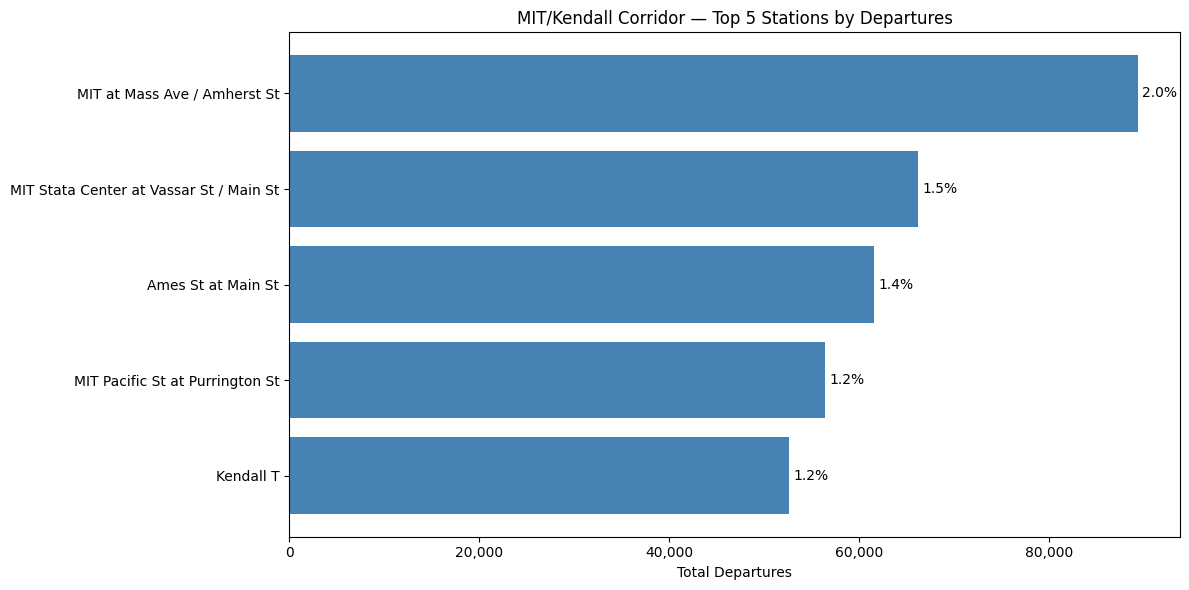

Saved: insight5c_mit_kendall.png


In [45]:
# 5c-viz: MIT/Kendall cluster — top 5 stations
mit_stations_top = mit_stations.head(5)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(mit_stations_top["start station name"][::-1],
        mit_stations_top["departures"][::-1], color="steelblue")
ax.set_title("MIT/Kendall Corridor — Top 5 Stations by Departures")
ax.set_xlabel("Total Departures")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

total_trips = len(df)
for i, (_, row) in enumerate(mit_stations_top[::-1].iterrows()):
    pct = row["departures"] / total_trips * 100
    ax.text(row["departures"] + 500, i, f"{pct:.1f}%", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR + "insight5c_mit_kendall.png", dpi=150)
plt.show()
print("Saved: insight5c_mit_kendall.png")


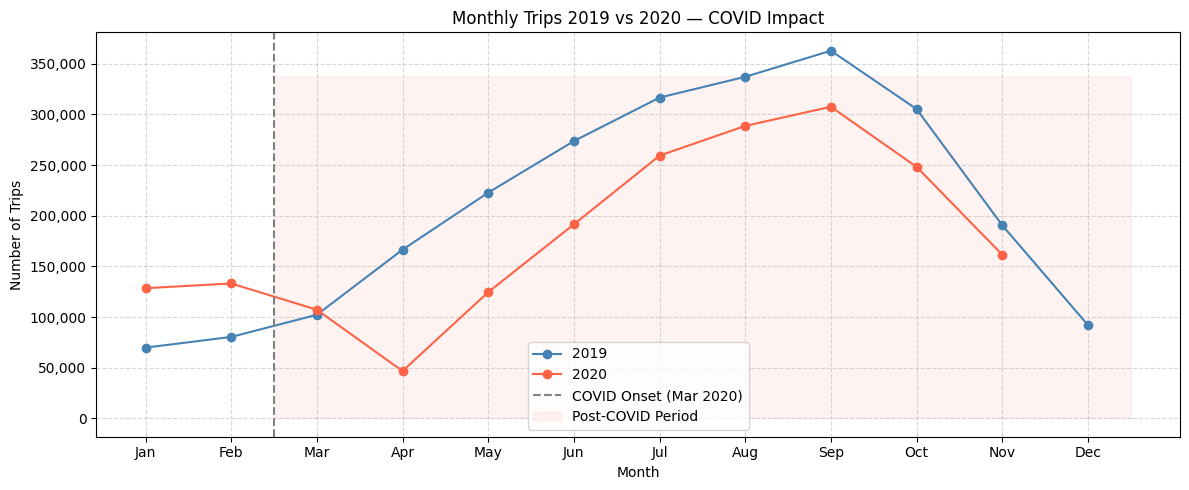

Saved: insight6_covid_impact.png


In [46]:
# INSIGHT 6: COVID-19 Impact — Pre vs. Post March 2020

# Split 2020 into Pre-COVID (Jan–Feb) and Post-COVID (Mar–Dec)
df_2020_only = df[df["year"] == 2020].copy()
df_2020_only["covid_period"] = df_2020_only["month"].apply(
    lambda m: "Pre-COVID (Jan–Feb)" if m <= 2 else "Post-COVID (Mar–Dec)"
)
 
monthly_2020 = (
    df_2020_only.groupby(["month", "month_name", "covid_period"])
    .size()
    .reset_index(name="trips")
    .sort_values("month")
)
 
# Also get 2019 monthly for comparison
monthly_2019 = (
    df[df["year"] == 2019]
    .groupby(["month", "month_name"])
    .size()
    .reset_index(name="trips")
    .sort_values("month")
)
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_2019["month"], monthly_2019["trips"], marker="o", label="2019", color="steelblue")
ax.plot(monthly_2020["month"], monthly_2020["trips"], marker="o", label="2020", color="tomato")
ax.axvline(x=2.5, color="gray", linestyle="--", linewidth=1.5, label="COVID Onset (Mar 2020)")
ax.fill_betweenx(
    [0, monthly_2020["trips"].max() * 1.1],
    2.5, 12.5, alpha=0.07, color="tomato", label="Post-COVID Period"
)
ax.set_title("Monthly Trips 2019 vs 2020 — COVID Impact")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Trips")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR + "insight6_covid_impact.png", dpi=150)
plt.show()
print("Saved: insight6_covid_impact.png")


Top 10 Stations — Weekdays:
                                         start station name  trips
                               MIT at Mass Ave / Amherst St  64375
                      Central Square at Mass Ave / Essex St  59800
                    MIT Stata Center at Vassar St / Main St  56134
                                         Ames St at Main St  51735
                           South Station - 700 Atlantic Ave  49604
                          Nashua Street at Red Auerbach Way  45323
                                                  Kendall T  43099
                            MIT Pacific St at Purrington St  41941
                Charles Circle - Charles St at Cambridge St  36859
Christian Science Plaza - Massachusetts Ave at Westland Ave  36678

Top 10 Stations — Weekends:
                                         start station name  trips
                               MIT at Mass Ave / Amherst St  24939
                      Central Square at Mass Ave / Essex St  23842
    

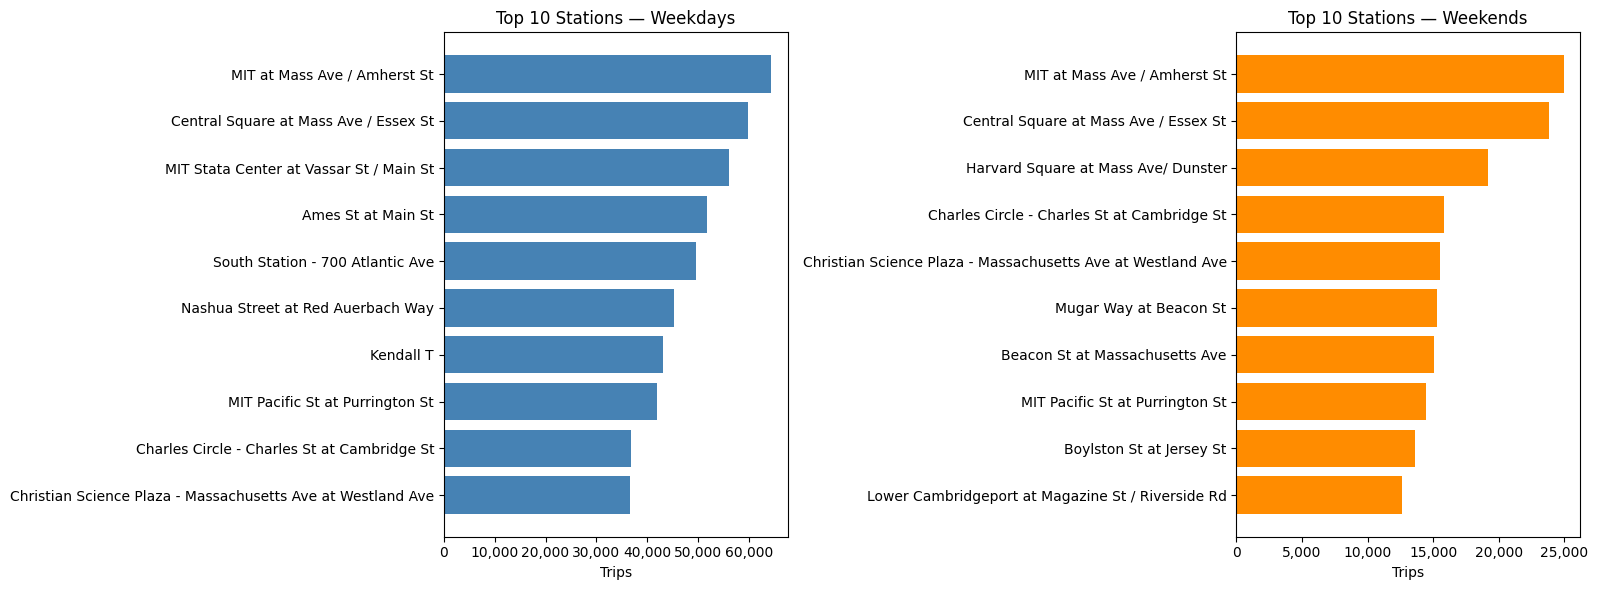

Saved: insight7_weekday_vs_weekend.png


In [47]:
# INSIGHT 7: Weekday vs. Weekend Station Rankings

station_weektype = (
    df.groupby(["start station name", "week_type"])
    .size()
    .reset_index(name="trips")
)
 
weekday_top = (
    station_weektype[station_weektype["week_type"] == "Weekday"]
    .sort_values("trips", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
weekend_top = (
    station_weektype[station_weektype["week_type"] == "Weekend"]
    .sort_values("trips", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
 
print("\nTop 10 Stations — Weekdays:")
print(weekday_top[["start station name", "trips"]].to_string(index=False))
 
print("\nTop 10 Stations — Weekends:")
print(weekend_top[["start station name", "trips"]].to_string(index=False))
 
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, data, title, color in zip(
    axes,
    [weekday_top, weekend_top],
    ["Top 10 Stations — Weekdays", "Top 10 Stations — Weekends"],
    ["steelblue", "darkorange"]
):
    ax.barh(data["start station name"][::-1], data["trips"][::-1], color=color)
    ax.set_title(title)
    ax.set_xlabel("Trips")
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
 
plt.tight_layout()
plt.savefig(OUT_DIR + "insight7_weekday_vs_weekend.png", dpi=150)
plt.show()
print("Saved: insight7_weekday_vs_weekend.png")

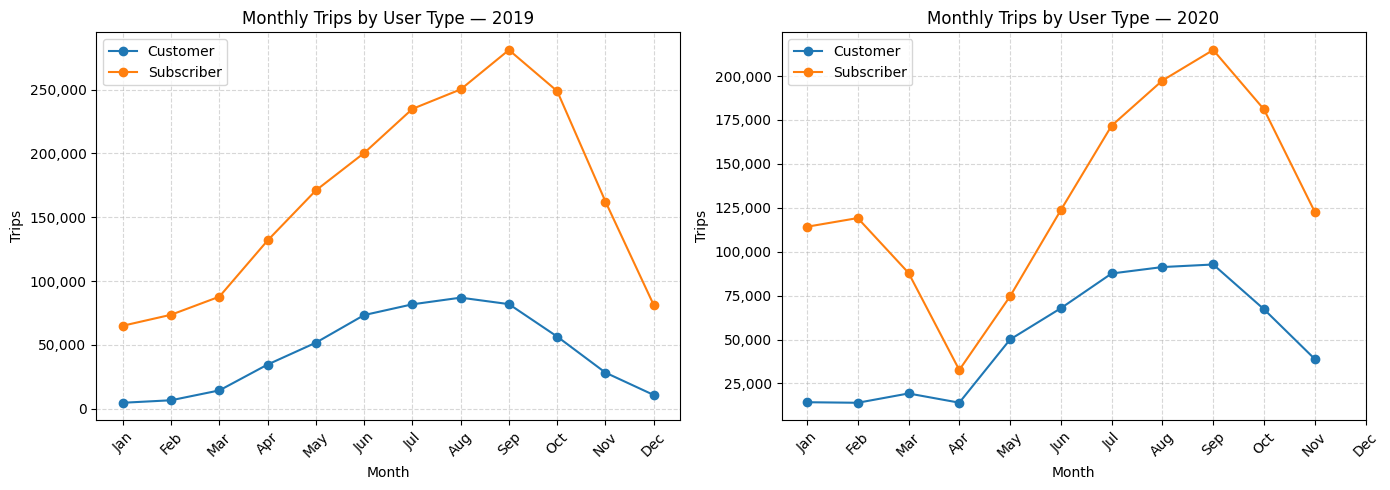

Saved: insight8_user_type.png


In [48]:
# INSIGHT 8: Subscriber vs. Casual Rider Behavior

user_monthly = (
    df.groupby(["year", "month", "usertype"])
    .size()
    .reset_index(name="trips")
    .sort_values(["year", "month"])
)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, yr in zip(axes, [2019, 2020]):
    subset = user_monthly[user_monthly["year"] == yr]
    for utype, grp in subset.groupby("usertype"):
        ax.plot(grp["month"], grp["trips"], marker="o", label=utype)
    ax.set_title(f"Monthly Trips by User Type — {yr}")
    ax.set_xlabel("Month")
    ax.set_ylabel("Trips")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(["Jan","Feb","Mar","Apr","May","Jun",
                        "Jul","Aug","Sep","Oct","Nov","Dec"], rotation=45)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
    ax.legend()
    ax.grid(True, linestyle="--", alpha=0.5)
 
plt.tight_layout()
plt.savefig(OUT_DIR + "insight8_user_type.png", dpi=150)
plt.show()
print("Saved: insight8_user_type.png")

In [49]:
# 8b: Subscriber vs Customer Composition Shift (2019 -> 2020)
# Subscribers (commuters) dropped 27.6% while Customers (casual) grew 4.6%.
# This changes how demand should be forecasted — two distinct rider populations.

user_summary = df.groupby(["year", "usertype"]).size().reset_index(name="trips")

sub_2019  = user_summary[(user_summary.year == 2019) & (user_summary.usertype == "Subscriber")]["trips"].values[0]
sub_2020  = user_summary[(user_summary.year == 2020) & (user_summary.usertype == "Subscriber")]["trips"].values[0]
cust_2019 = user_summary[(user_summary.year == 2019) & (user_summary.usertype == "Customer")]["trips"].values[0]
cust_2020 = user_summary[(user_summary.year == 2020) & (user_summary.usertype == "Customer")]["trips"].values[0]

print("Rider Composition Summary:")
print(f"  2019 Subscribers: {sub_2019:,}  |  Customers: {cust_2019:,}")
print(f"  2020 Subscribers: {sub_2020:,}  |  Customers: {cust_2020:,}")
print(f"\n  Subscriber YoY change: {(sub_2020 - sub_2019) / sub_2019 * 100:+.1f}%")
print(f"  Customer YoY change:   {(cust_2020 - cust_2019) / cust_2019 * 100:+.1f}%")
print(f"\n  Subscriber share: {sub_2019 / (sub_2019 + cust_2019) * 100:.1f}% (2019) "
      f"→ {sub_2020 / (sub_2020 + cust_2020) * 100:.1f}% (2020)")


Rider Composition Summary:
  2019 Subscribers: 1,987,988  |  Customers: 532,393
  2020 Subscribers: 1,440,093  |  Customers: 557,170

  Subscriber YoY change: -27.6%
  Customer YoY change:   +4.7%

  Subscriber share: 78.9% (2019) → 72.1% (2020)


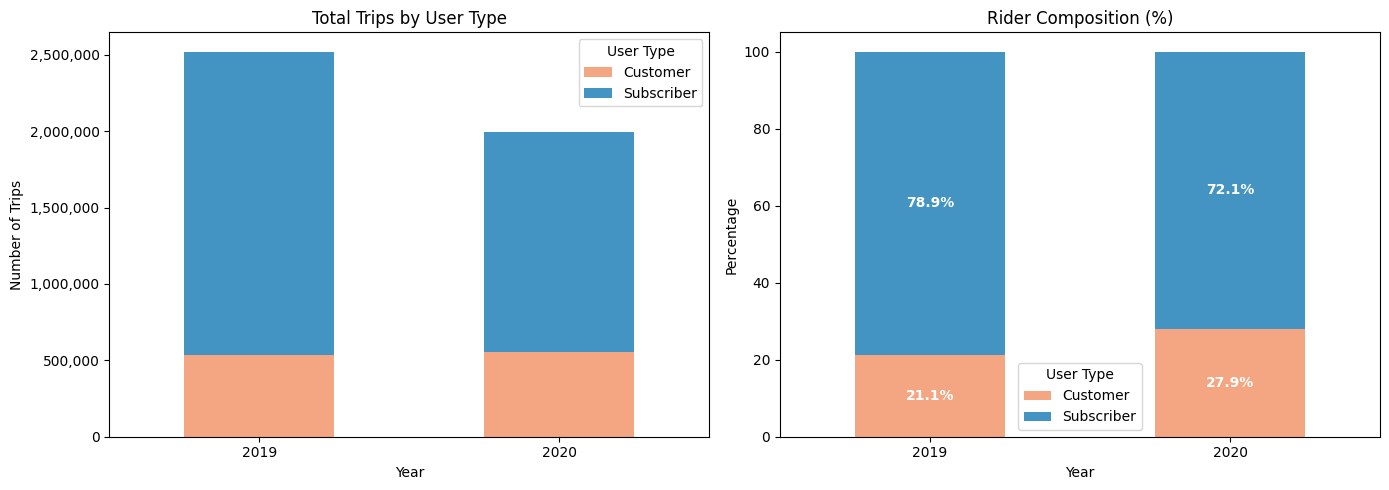

Saved: insight8b_user_composition.png


In [50]:
# 8c: Rider composition stacked bar chart (absolute + percentage)
pivot_user = user_summary.pivot(index="year", columns="usertype", values="trips")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pivot_user.plot(kind="bar", stacked=True, ax=axes[0], color=["#f4a582", "#4393c3"])
axes[0].set_title("Total Trips by User Type")
axes[0].set_ylabel("Number of Trips")
axes[0].set_xlabel("Year")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
axes[0].tick_params(axis="x", rotation=0)
axes[0].legend(title="User Type")

pivot_pct = pivot_user.div(pivot_user.sum(axis=1), axis=0) * 100
pivot_pct.plot(kind="bar", stacked=True, ax=axes[1], color=["#f4a582", "#4393c3"])
axes[1].set_title("Rider Composition (%)")
axes[1].set_ylabel("Percentage")
axes[1].set_xlabel("Year")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(title="User Type")
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f%%", label_type="center",
                      fontsize=10, color="white", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR + "insight8b_user_composition.png", dpi=150)
plt.show()
print("Saved: insight8b_user_composition.png")


In [51]:
# 8d: Trip duration breakdown by year and user type (median/mean/count)
# Customers ride roughly 2x longer per trip than Subscribers, and both groups rode longer in 2020.

# `dur` (trips filtered to 1-180 min) is reused from Insight 3
dur_stats = dur.groupby(["year", "usertype"])["duration_min"].agg(
    ["median", "mean", "count"]
).reset_index()
dur_stats.columns = ["year", "usertype", "median_min", "mean_min", "trip_count"]

print("Trip Duration by Year and User Type:")
print(dur_stats.to_string(index=False))

# Weekday vs Weekend share by user type
print("\nWeekday/Weekend Share by User Type:")
for ut in ["Subscriber", "Customer"]:
    sub = df[df.usertype == ut]
    wd = (sub.week_type == "Weekday").sum()
    we = (sub.week_type == "Weekend").sum()
    print(f"  {ut}: Weekday {wd:,} ({wd/(wd+we)*100:.0f}%) | Weekend {we:,} ({we/(wd+we)*100:.0f}%)")


Trip Duration by Year and User Type:
 year   usertype  median_min  mean_min  trip_count
 2019   Customer   21.100000 29.165544      527650
 2019 Subscriber   10.266667 12.851228     1986368
 2020   Customer   22.750000 32.668291      549855
 2020 Subscriber   11.583333 15.044924     1438752

Weekday/Weekend Share by User Type:
  Subscriber: Weekday 2,680,356 (78%) | Weekend 747,725 (22%)
  Customer: Weekday 617,400 (57%) | Weekend 472,163 (43%)


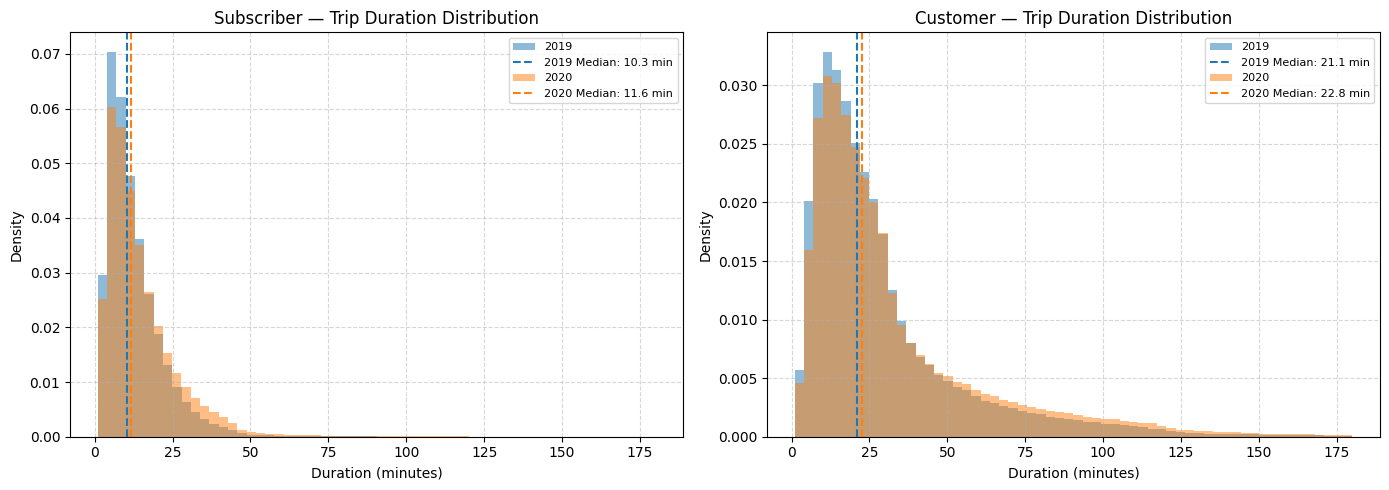

Saved: insight8d_duration_by_usertype.png


In [52]:
# 8e: Duration Distribution By User Type
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, ut in zip(axes, ["Subscriber", "Customer"]):
    for yr, color in [(2019, "#1f77b4"), (2020, "#ff7f0e")]:
        subset = dur[(dur.year == yr) & (dur.usertype == ut)]
        ax.hist(subset["duration_min"], bins=60, alpha=0.5, label=str(yr), density=True)
        med = subset["duration_min"].median()
        ax.axvline(med, color=color, linestyle="--", linewidth=1.5,
                   label=f"{yr} Median: {med:.1f} min")
    ax.set_title(f"{ut} — Trip Duration Distribution")
    ax.set_xlabel("Duration (minutes)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR + "insight8d_duration_by_usertype.png", dpi=150)
plt.show()
print("Saved: insight8d_duration_by_usertype.png")


In [53]:
# INSIGHT 9: Stations with Consistent Ride Time Errors

# Anomalous trips are used as a proxy for bike/dock issues:
#   - Under 1 min  = likely docking error or immediate mechanical failure
#   - Over 24 hrs  = likely abandonment, theft, or severe malfunction
# Note: we use df_raw (pre-filter) here because the cleaning step in 2e already
# removed trips outside [1 min, 24 hr] from df. Those are exactly the trips we
# want to flag as anomalies.
 
df_raw["duration_min"] = df_raw["tripduration"] / 60
df_raw["is_too_short"] = df_raw["duration_min"] < 1
df_raw["is_too_long"]  = df_raw["duration_min"] > 1440   # 24 hours = 1440 minutes
df_raw["is_anomalous"] = df_raw["is_too_short"] | df_raw["is_too_long"]

print(f"Total trips in raw data: {len(df_raw):,}")
print(f"Anomalous trips found:   {df_raw['is_anomalous'].sum():,} "
      f"({df_raw['is_anomalous'].mean()*100:.2f}%)")


Total trips in raw data: 4,522,217
Anomalous trips found:   4,573 (0.10%)


In [54]:
# 9a. Error rate per station (using df_raw so anomalies aren't already filtered out)
station_errors = (
    df_raw.groupby("start station name")
    .agg(
        total_trips   = ("is_anomalous", "count"),
        anomalous_trips = ("is_anomalous", "sum")
    )
    .reset_index()
)
station_errors["error_rate_pct"] = (
    station_errors["anomalous_trips"] / station_errors["total_trips"] * 100
).round(2)
station_errors = station_errors.sort_values("anomalous_trips", ascending=False).reset_index(drop=True)
 
print("\nTop 15 Stations by Anomalous Trip Count (Repair Priority):")
print(station_errors.head(15).to_string(index=False))



Top 15 Stations by Anomalous Trip Count (Repair Priority):
                                             start station name  total_trips  anomalous_trips  error_rate_pct
                               South Station - 700 Atlantic Ave        56908               66            0.12
                    Copley Square - Dartmouth St at Boylston St        31791               59            0.19
                             Aquarium T Stop - 200 Atlantic Ave        28913               55            0.19
                                     Seaport Blvd at Sleeper St        32071               54            0.17
    Christian Science Plaza - Massachusetts Ave at Westland Ave        52278               53            0.10
Newmarket Square T Stop - Massachusetts Ave at Newmarket Square         6755               53            0.78
                                                 Kenmore Square        28033               52            0.19
                                 Boston City Hall - 28 State

In [55]:
# 9b. Check consistency — stations with errors in both years (using df_raw)
errors_by_year = (
    df_raw[df_raw["is_anomalous"]]
    .groupby(["start station name", "year"])
    .size()
    .reset_index(name="anomalous_trips")
)
consistent_errors = (
    errors_by_year.groupby("start station name")["year"]
    .nunique()
    .reset_index(name="years_with_errors")
)
consistent_errors = consistent_errors[consistent_errors["years_with_errors"] == 2]
consistent_errors = consistent_errors.merge(station_errors, on="start station name")
consistent_errors = consistent_errors.sort_values("anomalous_trips", ascending=False).reset_index(drop=True)
 
print("\nStations with Consistent Errors in BOTH 2019 & 2020 (Highest Repair Priority):")
print(consistent_errors.head(15).to_string(index=False))



Stations with Consistent Errors in BOTH 2019 & 2020 (Highest Repair Priority):
                                             start station name  years_with_errors  total_trips  anomalous_trips  error_rate_pct
                               South Station - 700 Atlantic Ave                  2        56908               66            0.12
                    Copley Square - Dartmouth St at Boylston St                  2        31791               59            0.19
                             Aquarium T Stop - 200 Atlantic Ave                  2        28913               55            0.19
                                     Seaport Blvd at Sleeper St                  2        32071               54            0.17
    Christian Science Plaza - Massachusetts Ave at Westland Ave                  2        52278               53            0.10
Newmarket Square T Stop - Massachusetts Ave at Newmarket Square                  2         6755               53            0.78
                 

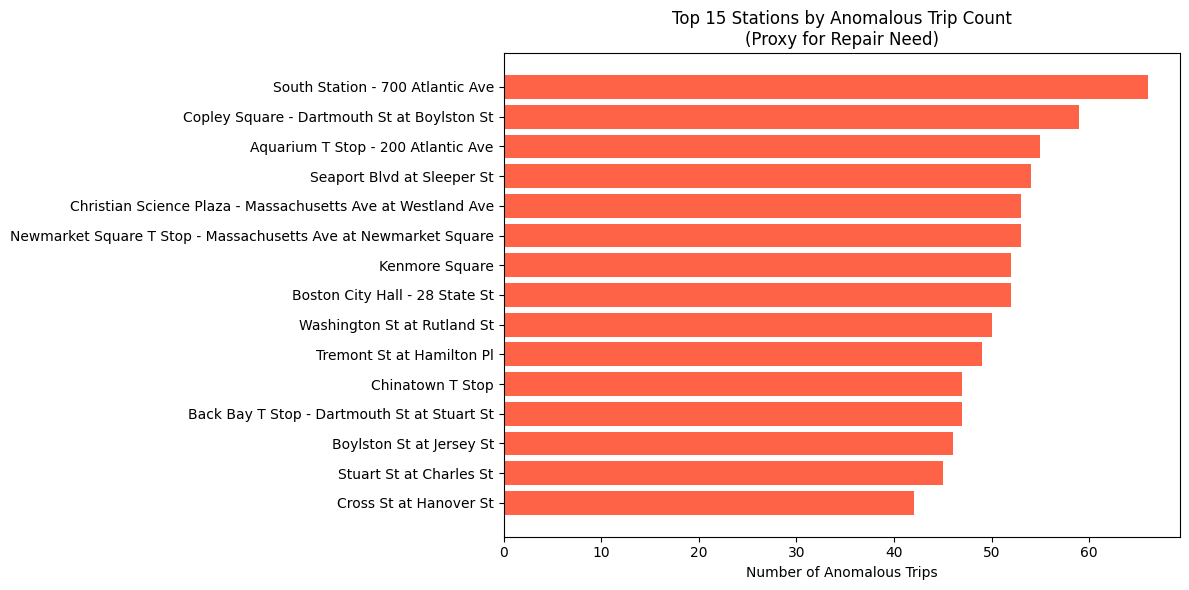

Saved: insight9_repair_priority_stations.png


In [56]:
# 9c. Plot top 15 stations by anomalous trip count
top15_errors = station_errors.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top15_errors["start station name"][::-1], top15_errors["anomalous_trips"][::-1], color="tomato")
ax.set_title("Top 15 Stations by Anomalous Trip Count\n(Proxy for Repair Need)")
ax.set_xlabel("Number of Anomalous Trips")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
plt.tight_layout()
plt.savefig(OUT_DIR + "insight9_repair_priority_stations.png", dpi=150)
plt.show()
print("Saved: insight9_repair_priority_stations.png")

In [57]:
# INSIGHT 10: Optimal Month for Bike Repair / Refurbishment per Station

# The best month for maintenance = lowest departure volume per station
# (fewest disruptions when bikes are taken offline)

station_monthly_trips = (
    df.groupby(["start station name", "month"])
    .size()
    .reset_index(name="trips")
)
 
# Find the single lowest-demand month per station
optimal_repair_month = (
    station_monthly_trips
    .loc[station_monthly_trips.groupby("start station name")["trips"].idxmin()]
    .reset_index(drop=True)
)
optimal_repair_month.columns = ["station", "best_repair_month", "trips_that_month"]
 
# Map month number to name
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
             7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
optimal_repair_month["best_repair_month_name"] = (
    optimal_repair_month["best_repair_month"].map(month_map)
)
 
print("\nOptimal Repair Month per Station (sample — top 20 busiest):")
top20 = station_errors.head(20)["start station name"].tolist()
print(
    optimal_repair_month[optimal_repair_month["station"].isin(top20)]
    .to_string(index=False)
)
 


Optimal Repair Month per Station (sample — top 20 busiest):
                                                        station  best_repair_month  trips_that_month best_repair_month_name
                             Aquarium T Stop - 200 Atlantic Ave                 12               538                    Dec
                    Back Bay T Stop - Dartmouth St at Stuart St                 12               926                    Dec
                                 Boston City Hall - 28 State St                 12               701                    Dec
                                           Boston Public Market                 12               526                    Dec
                                       Boylston St at Exeter St                 12               633                    Dec
                                       Boylston St at Jersey St                 12               881                    Dec
                                               Chinatown T Stop        

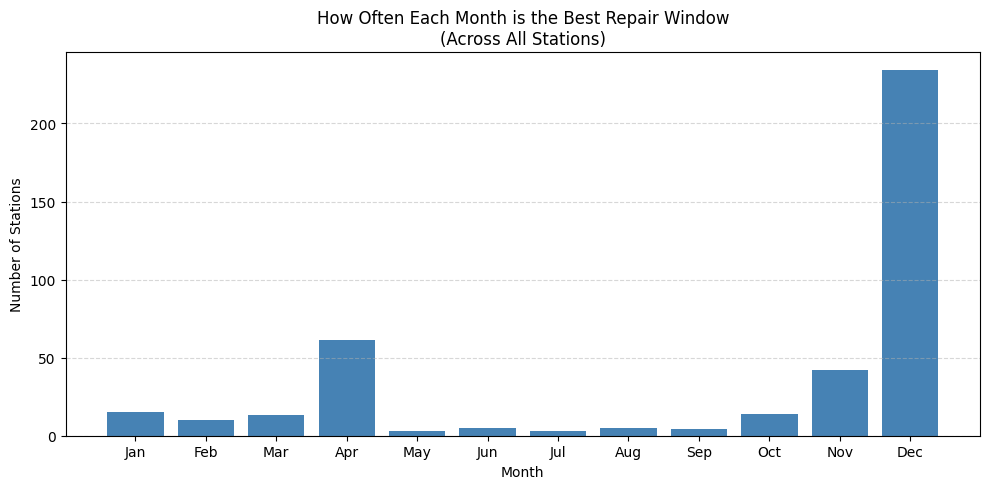

Saved: insight10_optimal_repair_month.png


In [58]:
# 10b. Which months are most commonly the best repair window?
repair_month_dist = (
    optimal_repair_month["best_repair_month_name"]
    .value_counts()
    .reindex(["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"])
    .fillna(0)
)
 
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(repair_month_dist.index, repair_month_dist.values, color="steelblue")
ax.set_title("How Often Each Month is the Best Repair Window\n(Across All Stations)")
ax.set_xlabel("Month")
ax.set_ylabel("Number of Stations")
ax.grid(True, linestyle="--", alpha=0.5, axis="y")
plt.tight_layout()
plt.savefig(OUT_DIR + "insight10_optimal_repair_month.png", dpi=150)
plt.show()
print("Saved: insight10_optimal_repair_month.png")

In [59]:
# 10c: Seasonal Demand Swing (peak-to-trough ratio)
# Winter months are a clear maintenance window.

monthly_total = df.groupby(["month", "month_name"]).size().reset_index(name="trips")
monthly_total = monthly_total.sort_values("month")

peak_month   = monthly_total.loc[monthly_total["trips"].idxmax()]
trough_month = monthly_total.loc[monthly_total["trips"].idxmin()]
ratio = peak_month["trips"] / trough_month["trips"]

print("Monthly Demand Summary (2019 + 2020 Combined):")
for _, row in monthly_total.iterrows():
    bar = "█" * int(row["trips"] / 20000)
    print(f"  {row['month_name']:>3}: {row['trips']:>10,}  {bar}")

print(f"\nPeak Month:   {peak_month['month_name']} ({peak_month['trips']:,} trips)")
print(f"Trough Month: {trough_month['month_name']} ({trough_month['trips']:,} trips)")
print(f"Peak-to-Trough Ratio: {ratio:.1f}x")


Monthly Demand Summary (2019 + 2020 Combined):
  Jan:    198,317  █████████
  Feb:    213,524  ██████████
  Mar:    209,479  ██████████
  Apr:    213,207  ██████████
  May:    347,447  █████████████████
  Jun:    465,262  ███████████████████████
  Jul:    576,039  ████████████████████████████
  Aug:    625,893  ███████████████████████████████
  Sep:    670,522  █████████████████████████████████
  Oct:    553,596  ███████████████████████████
  Nov:    352,239  █████████████████
  Dec:     92,119  ████

Peak Month:   Sep (670,522 trips)
Trough Month: Dec (92,119 trips)
Peak-to-Trough Ratio: 7.3x


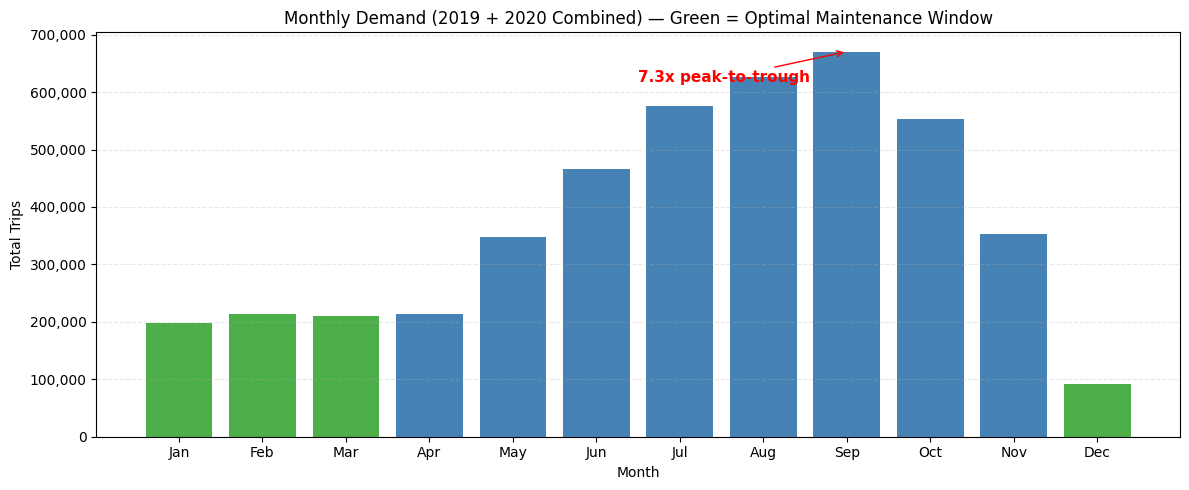

Saved: insight10c_seasonal_demand.png


In [60]:
# 10d: Monthly Demand Bar Chart with Maintenance Window Highlighted
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

# Green = low-demand months (good maintenance window)
colors = ["#4daf4a" if m in [12, 1, 2, 3] else "steelblue"
          for m in monthly_total["month"]]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(monthly_total["month"], monthly_total["trips"], color=colors)

ax.set_title("Monthly Demand (2019 + 2020 Combined) — Green = Optimal Maintenance Window")
ax.set_xlabel("Month")
ax.set_ylabel("Total Trips")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

ax.annotate(f"{ratio:.1f}x peak-to-trough",
            xy=(9, peak_month["trips"]),
            xytext=(6.5, peak_month["trips"] * 0.92),
            fontsize=11, fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="red"),
            color="red")

ax.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR + "insight10c_seasonal_demand.png", dpi=150)
plt.show()
print("Saved: insight10c_seasonal_demand.png")


In [61]:
# INSIGHT 11: Average Bike Turnaround Time (Idle time between consecutive trips per bike)

# Turnaround time = gap between stoptime of one trip and starttime of the next trip for the same bikeid.

# Sort all trips by bike and departure time
df_sorted = df[["bikeid", "starttime", "stoptime"]].dropna().sort_values(
    ["bikeid", "starttime"]
).reset_index(drop=True)
 
# Shift within each bike group to align consecutive trips
df_sorted["next_starttime"] = df_sorted.groupby("bikeid")["starttime"].shift(-1)
 
# Turnaround = next departure − current return
df_sorted["turnaround_min"] = (
    df_sorted["next_starttime"] - df_sorted["stoptime"]
).dt.total_seconds() / 60
 
# Keep only valid positive turnarounds under 7 days (filter out long storage gaps)
turnaround = df_sorted[
    (df_sorted["turnaround_min"] > 0) &
    (df_sorted["turnaround_min"] <= 10080)   # 7 days in minutes
]
 
avg_turnaround   = turnaround["turnaround_min"].mean()
median_turnaround = turnaround["turnaround_min"].median()
 
print(f"\nAverage Bike Turnaround Time : {avg_turnaround:.1f} minutes  ({avg_turnaround/60:.1f} hours)")
print(f"Median  Bike Turnaround Time : {median_turnaround:.1f} minutes  ({median_turnaround/60:.1f} hours)")


Average Bike Turnaround Time : 472.0 minutes  (7.9 hours)
Median  Bike Turnaround Time : 109.2 minutes  (1.8 hours)


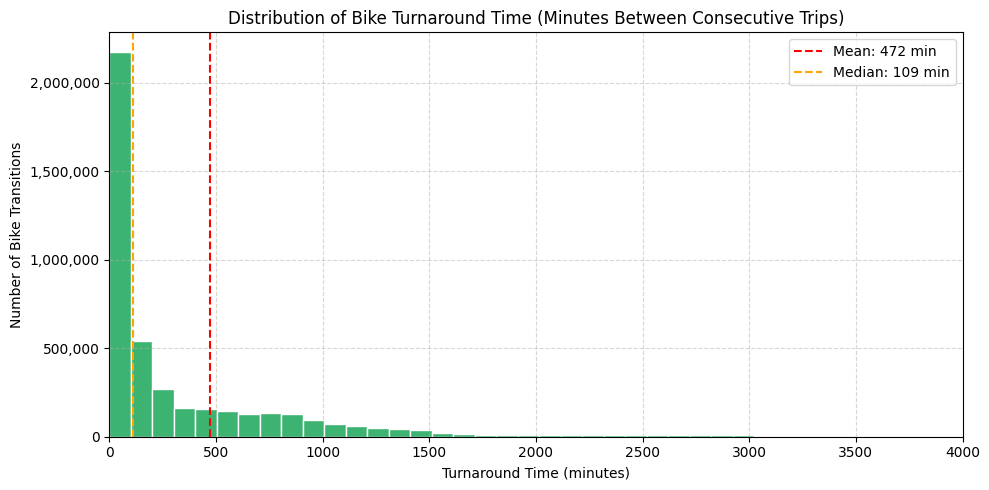

Saved: insight11_bike_turnaround.png


In [62]:
# 11b. Distribution plot
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(turnaround["turnaround_min"], bins=100, color="mediumseagreen", edgecolor="white")
ax.axvline(avg_turnaround,    color="red",    linestyle="--", linewidth=1.5, label=f"Mean: {avg_turnaround:.0f} min")
ax.axvline(median_turnaround, color="orange", linestyle="--", linewidth=1.5, label=f"Median: {median_turnaround:.0f} min")
ax.set_title("Distribution of Bike Turnaround Time (Minutes Between Consecutive Trips)")
ax.set_xlabel("Turnaround Time (minutes)")
ax.set_ylabel("Number of Bike Transitions")
ax.set_xlim(0, 4000)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig(OUT_DIR + "insight11_bike_turnaround.png", dpi=150)
plt.show()
print("Saved: insight11_bike_turnaround.png")

In [63]:
# 11c. Average turnaround by year
df_sorted["year"] = df_sorted["starttime"].dt.year
turnaround_yr = df_sorted[
    (df_sorted["turnaround_min"] > 0) &
    (df_sorted["turnaround_min"] <= 10080)
].groupby("year")["turnaround_min"].agg(["mean", "median"]).reset_index()
turnaround_yr.columns = ["year", "mean_min", "median_min"]
print("\nAverage Turnaround Time by Year:")
print(turnaround_yr.to_string(index=False))


Average Turnaround Time by Year:
 year   mean_min  median_min
 2019 423.302058   95.454800
 2020 533.504736  129.057692


In [67]:
# INSIGHT 12: Optimal Total Number of Bikes in the System (Based on Peak Concurrent Usage)

# Approach: count how many trips were active at every minute of the day to find peak simultaneous bike usage.
# Fleet recommendation = peak usage + safety buffer (20%).

# Event-based approach: +1 at each trip start, -1 at each trip end
# Cumulative sum gives concurrent active bikes at every event — very fast
print("Concurrent usage:")
 
trips_valid = df[["starttime", "stoptime"]].dropna()
 
starts = pd.DataFrame({"time": trips_valid["starttime"], "event": 1})
ends   = pd.DataFrame({"time": trips_valid["stoptime"],  "event": -1})
 
events = pd.concat([starts, ends]).sort_values("time").reset_index(drop=True)
events["concurrent"] = events["event"].cumsum()
 
# Build a time-indexed series for resampling
concurrent_series = events.set_index("time")["concurrent"]
 
peak_usage      = int(concurrent_series.max())
avg_usage       = float(concurrent_series.mean())
recommended_fleet = int(peak_usage * 1.20)   # 20% buffer
 
print(f"\nPeak Concurrent Bikes in Use : {peak_usage:,}")
print(f"Average Concurrent Bikes    : {avg_usage:,.1f}")
print(f"Recommended Fleet Size      : {recommended_fleet:,}  (peak + 20% buffer)")
 
# Actual unique bikes in the dataset
actual_bikes = df["bikeid"].nunique()
print(f"Actual Unique Bikes in Data : {actual_bikes:,}")
print(f"Gap (Recommended − Actual)  : {recommended_fleet - actual_bikes:+,}")
print(f"Fleet Utilization at Peak   : {peak_usage / actual_bikes * 100:.1f}%")
print(f"Idle Bikes at Peak          : {actual_bikes - peak_usage:,}")

Concurrent usage:

Peak Concurrent Bikes in Use : 872
Average Concurrent Bikes    : 188.4
Recommended Fleet Size      : 1,046  (peak + 20% buffer)
Actual Unique Bikes in Data : 4,987
Gap (Recommended − Actual)  : -3,941
Fleet Utilization at Peak   : 17.5%
Idle Bikes at Peak          : 4,115


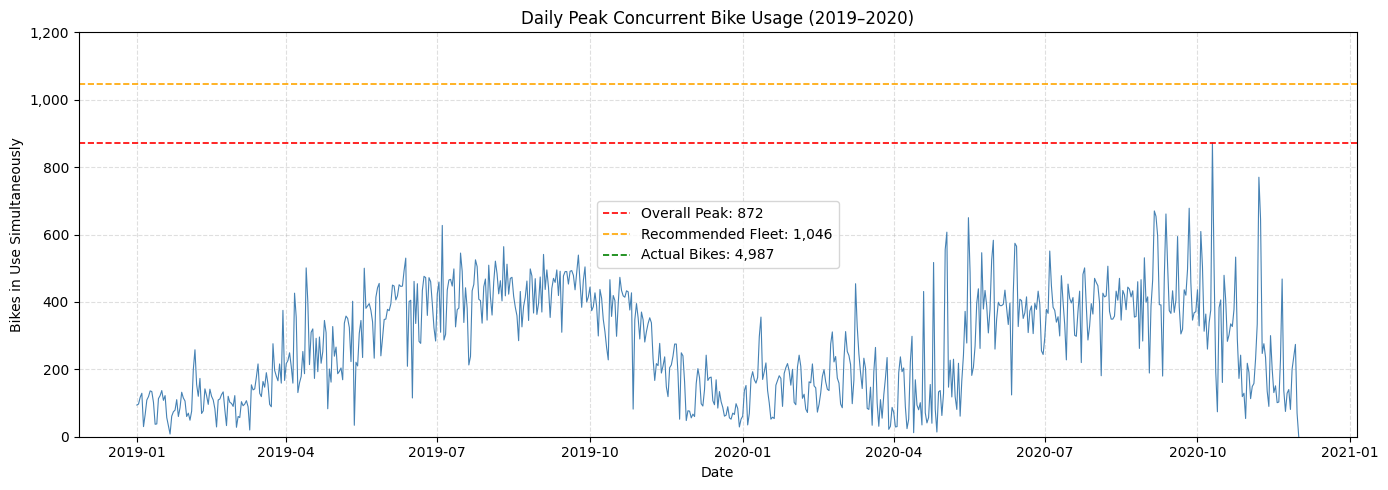

Saved: insight12_optimal_fleet_size.png


In [69]:
# 12b. Plot concurrent usage over time (daily peaks)
daily_peak = concurrent_series.resample("D").max().dropna().reset_index()
daily_peak.columns = ["date", "peak_concurrent"]
 
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(daily_peak["date"], daily_peak["peak_concurrent"], color="steelblue", linewidth=0.8)
ax.axhline(peak_usage,        color="red",    linestyle="--", linewidth=1.2, label=f"Overall Peak: {peak_usage:,}")
ax.axhline(recommended_fleet, color="orange", linestyle="--", linewidth=1.2, label=f"Recommended Fleet: {recommended_fleet:,}")
ax.axhline(actual_bikes,      color="green",  linestyle="--", linewidth=1.2, label=f"Actual Bikes: {actual_bikes:,}")
ax.set_title("Daily Peak Concurrent Bike Usage (2019–2020)")
ax.set_xlabel("Date")
ax.set_ylabel("Bikes in Use Simultaneously")
ax.set_ylim(0, 1200)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR + "insight12_optimal_fleet_size.png", dpi=150)
plt.show()
print("Saved: insight12_optimal_fleet_size.png")

In [70]:
# EXPORT: Export Summary Results into Tables

top_pairs.to_csv(OUT_DIR + "top_station_pairs.csv", index=False)
weekday_top.to_csv(OUT_DIR + "top_weekday_stations.csv", index=False)
weekend_top.to_csv(OUT_DIR + "top_weekend_stations.csv", index=False)
monthly_2020.to_csv(OUT_DIR + "monthly_2020_covid.csv", index=False)
station_errors.to_csv(OUT_DIR + "station_repair_priority.csv", index=False)
optimal_repair_month.to_csv(OUT_DIR + "optimal_repair_month_per_station.csv", index=False)
 
print("\nAll CSVs saved:")
print("  - top_station_pairs.csv")
print("  - top_weekday_stations.csv")
print("  - top_weekend_stations.csv")
print("  - monthly_2020_covid.csv")
print("  - station_repair_priority.csv")
print("  - optimal_repair_month_per_station.csv")

# Additional finding tables
user_summary.to_csv(OUT_DIR + "finding_user_composition.csv", index=False)
mit_stations.to_csv(OUT_DIR + "finding_mit_kendall_stations.csv", index=False)
dur_stats.to_csv(OUT_DIR + "finding_duration_stats.csv", index=False)
monthly_total.to_csv(OUT_DIR + "finding_monthly_demand.csv", index=False)

print("\nAdditional finding CSVs saved:")
print("  - finding_user_composition.csv")
print("  - finding_mit_kendall_stations.csv")
print("  - finding_duration_stats.csv")
print("  - finding_monthly_demand.csv")



All CSVs saved:
  - top_station_pairs.csv
  - top_weekday_stations.csv
  - top_weekend_stations.csv
  - monthly_2020_covid.csv
  - station_repair_priority.csv
  - optimal_repair_month_per_station.csv

Additional finding CSVs saved:
  - finding_user_composition.csv
  - finding_mit_kendall_stations.csv
  - finding_duration_stats.csv
  - finding_monthly_demand.csv



# ============================================================
# Insight 13: Capacity Decision Optimization (Newsvendor Model)
# ============================================================

Author of original optimization script: Professor Vishal Gaur, Cornell University (Mar 7, 2023). Adapted by Team 2 for Bluebikes.

This section uses the Newsvendor model under demand uncertainty to recommend an optimal per-station bike allocation. Steps:

1. Build daily demand per station from the cleaned dataframe.
2. Forecast 2021 monthly demand per station using Simple Exponential Smoothing (SES).
3. Estimate per-station per-month standard deviation from history.
4. Compute optimal stock at multiple critical ratios (0.80–0.95) via the inverse normal CDF.
5. Scale to the actual fleet to get a recommended bike allocation per station.


In [71]:
# INSIGHT 13: Forecasting Future Demand with a Newsvendor Model
# Additional imports for the Newsvendor capacity model
from statsmodels.tsa.holtwinters import SimpleExpSmoothing
from scipy.stats import norm

In [72]:
# 13a. Daily demand per station (reusing the cleaned df from earlier)
daily_demand = (
    df.groupby(['year', 'month', 'start station name', 'date'])
    .size()
    .reset_index(name='daily_trips')
)

print(f"Daily-demand rows: {len(daily_demand):,}")
print(daily_demand.head())


Daily-demand rows: 190,754
   year  month start station name        date  daily_trips
0  2019      1   175 N Harvard St  2019-01-01            8
1  2019      1   175 N Harvard St  2019-01-02            8
2  2019      1   175 N Harvard St  2019-01-03            7
3  2019      1   175 N Harvard St  2019-01-04           16
4  2019      1   175 N Harvard St  2019-01-05            1


In [74]:
# 13b. Total fleet size = avg number of unique bikes seen on a random day
# (Insight 12 above used a peak-concurrent approach; here we use the simpler
#  daily-unique-bike average because we want a sustainable allocation target)
total_fleet_capacity = df.groupby('date')['bikeid'].nunique().mean()
print(f"Estimated total fleet size on a random day: {total_fleet_capacity:.0f} bikes")

Estimated total fleet size on a random day: 1646 bikes


In [76]:
# 13b-2. Backtest: train on 2019 only, forecast 2020, compare to actual 2020
# Training on 2019 and forecasting 2020 gives us a measurable error (MAE/MAPE)that tells us how much to trust the 2021 predictions

backtest_results = []

for station, group in daily_demand.groupby('start station name'):
    # Use only 2019 data for training
    group_2019 = group[group['year'] == 2019].sort_values('date').set_index('date')
    if len(group_2019) == 0:
        continue

    full_range = pd.date_range(start=group_2019.index.min(), end=group_2019.index.max(), freq='D')
    group_2019 = group_2019.reindex(full_range, fill_value=0)
    monthly_2019 = group_2019[['daily_trips']].resample('ME').sum()

    if len(monthly_2019) < 6:
        continue

    try:
        model = SimpleExpSmoothing(
            monthly_2019['daily_trips'],
            initialization_method='estimated'
        ).fit(smoothing_level=None, optimized=True)
        forecast_2020 = model.forecast(12).clip(lower=0)
    except Exception:
        continue

    # Get actual 2020 monthly demand for this station
    actual_2020 = (
        group[group['year'] == 2020]
        .groupby('month')['daily_trips'].sum()
    )

    for month in range(1, 13):
        if month not in actual_2020.index:
            continue
        actual = actual_2020[month]
        predicted = forecast_2020.iloc[month - 1] if month <= len(forecast_2020) else None
        if predicted is None:
            continue
        backtest_results.append({
            'station': station,
            'month': month,
            'actual': actual,
            'predicted': round(predicted, 2),
            'abs_error': round(abs(predicted - actual), 2),
            'pct_error': round(abs(predicted - actual) / actual * 100, 1) if actual > 0 else None,
        })

backtest_df = pd.DataFrame(backtest_results)

mae  = backtest_df['abs_error'].mean()
mape = backtest_df['pct_error'].dropna().mean()

print(f"Backtest Results (Train: 2019 → Forecast: 2020):")
print(f"  Mean Absolute Error (MAE):  {mae:.1f} trips/month per station")
print(f"  Mean Abs Pct Error (MAPE):  {mape:.1f}%")
print(f"\nMAPE by Month:")
print(backtest_df.groupby('month')['pct_error'].mean().round(1).to_string())

backtest_df.to_csv(OUT_DIR + 'forecast_backtest_2020.csv', index=False)
print("\nSaved: forecast_backtest_2020.csv")

Backtest Results (Train: 2019 → Forecast: 2020):
  Mean Absolute Error (MAE):  317.3 trips/month per station
  Mean Abs Pct Error (MAPE):  157.6%

MAPE by Month:
month
1       38.1
2       35.4
3     1083.3
4      179.5
5       60.5
6       72.4
7       70.4
8       65.0
9       64.9
10      58.6
11      65.3

Saved: forecast_backtest_2020.csv


In [77]:
# MAPE excluding COVID shock months (March-April 2020)
mape_excl_covid = backtest_df[~backtest_df['month'].isin([3, 4])]['pct_error'].dropna().mean()
print(f"MAPE excluding COVID shock months (Mar-Apr): {mape_excl_covid:.1f}%")

MAPE excluding COVID shock months (Mar-Apr): 59.7%


In [79]:
# 13c. Forecast 2021 monthly demand per station using Simple Exponential Smoothing
forecast_results = []
skipped_stations = []
ses_stations = []
historical_stations = []

for station, group in daily_demand.groupby('start station name'):
    group = group.sort_values('date').set_index('date')

    # Fill missing dates with 0
    full_range = pd.date_range(start=group.index.min(), end=group.index.max(), freq='D')
    group = group.reindex(full_range, fill_value=0)

    # Monthly aggregation
    monthly = group[['daily_trips']].resample('ME').sum()

    # Skip stations with less than 12 months of data
    if len(monthly) < 12:
        skipped_stations.append(station)
        continue

    # How many months ahead to reach end of 2021
    last_month = monthly.index[-1]
    target_end = pd.Timestamp('2021-12-31')
    months_to_forecast = (target_end.year - last_month.year) * 12 + (target_end.month - last_month.month)

    if months_to_forecast <= 0:
        skipped_stations.append(station)
        continue

    try:
        model = SimpleExpSmoothing(
            monthly['daily_trips'],
            initialization_method='estimated'
        ).fit(smoothing_level=None, optimized=True)
        forecast = model.forecast(months_to_forecast)
        forecast = forecast[forecast.index.year == 2021]
        ses_stations.append(station)
    except Exception:
        # Fall back to historical mean if SES fails
        hist_mean = monthly['daily_trips'].mean()
        forecast_index = pd.date_range(start=pd.Timestamp('2021-01-31'), periods=12, freq='ME')
        forecast = pd.Series([hist_mean] * 12, index=forecast_index)
        historical_stations.append(station)

    forecast_df = pd.DataFrame({
        'forecasted_trips': forecast.values,
        'start station name': str(station),
        'year': forecast.index.year.astype(int),
        'month': forecast.index.month.astype(int),
    })
    forecast_results.append(forecast_df)

print(f"Stations forecasted with SES:               {len(ses_stations)}")
print(f"Stations forecasted with historical mean:   {len(historical_stations)}")
print(f"Stations skipped (insufficient data):       {len(skipped_stations)}")
print(f"Total stations successfully forecasted:     {len(forecast_results)}")

# Combine SES forecasts into one DataFrame before adding skipped station fallbacks
all_forecasts = pd.concat(forecast_results, ignore_index=True)

# Handle skipped stations with historical mean fallback (assign them their historical monthly mean as a simple forecast so they receive a baseline allocation rather than nothing)
skipped_fallback = []

for station in skipped_stations:
    group = daily_demand[daily_demand['start station name'] == station]
    if len(group) == 0:
        continue

    # Average daily trips per month across all available history
    monthly_mean = group.groupby('month')['daily_trips'].mean()

    for month, mean_val in monthly_mean.items():
        skipped_fallback.append({
            'forecasted_trips': mean_val,
            'start station name': str(station),
            'year': 2021,
            'month': int(month),
        })

if skipped_fallback:
    skipped_df = pd.DataFrame(skipped_fallback)
    all_forecasts = pd.concat([all_forecasts, skipped_df], ignore_index=True)
    print(f"Added fallback forecasts for {len(skipped_stations)} skipped stations")
    print(f"Total stations now covered: {all_forecasts['start station name'].nunique()}")
else:
    print("No skipped stations to add fallback for")


Stations forecasted with SES:               336
Stations forecasted with historical mean:   0
Stations skipped (insufficient data):       73
Total stations successfully forecasted:     336
Added fallback forecasts for 73 skipped stations
Total stations now covered: 409


In [85]:
# 13c-2. Demand comparison table: 2019 actual, 2020 actual, 2021 predicted

# Actual monthly demand per station for 2019
actual_2019 = (
    daily_demand[daily_demand['year'] == 2019]
    .groupby(['start station name', 'month'])['daily_trips']
    .sum()
    .reset_index()
)
actual_2019.columns = ['station', 'month', 'actual_demand_2019']

# Actual monthly demand per station for 2020
actual_2020 = (
    daily_demand[daily_demand['year'] == 2020]
    .groupby(['start station name', 'month'])['daily_trips']
    .sum()
    .reset_index()
)
actual_2020.columns = ['station', 'month', 'actual_demand_2020']

# Predicted 2021 demand from all_forecasts
predicted_2021 = (
    all_forecasts.groupby(['start station name', 'month'])['forecasted_trips']
    .mean()
    .reset_index()
)
predicted_2021.columns = ['station', 'month', 'predicted_demand_2021']
predicted_2021['predicted_demand_2021'] = predicted_2021['predicted_demand_2021'].round(0).astype(int)


# Merge all three into one table
demand_comparison = (
    predicted_2021
    .merge(actual_2019, on=['station', 'month'], how='left')
    .merge(actual_2020, on=['station', 'month'], how='left')
)[['month', 'station', 'actual_demand_2019', 'actual_demand_2020', 'predicted_demand_2021']]

demand_comparison = demand_comparison.sort_values(['month', 'station']).reset_index(drop=True)

# Check station coverage
stations_in_comparison = demand_comparison['station'].nunique()
stations_in_daily_demand = daily_demand['start station name'].nunique()
stations_in_forecast = all_forecasts['start station name'].nunique()

print(f"Stations in original dataset:    {stations_in_daily_demand}")
print(f"Stations in forecast (2021):     {stations_in_forecast}")
print(f"Stations in comparison table:    {stations_in_comparison}")
print(f"Missing from forecast:           {stations_in_daily_demand - stations_in_comparison}")

print("\nSample output:")
print(demand_comparison.head(20).to_string(index=False))

demand_comparison.to_csv(OUT_DIR + 'demand_comparison_2019_2020_2021.csv', index=False)
print("\nSaved: demand_comparison_2019_2020_2021.csv")

Stations in original dataset:    409
Stations in forecast (2021):     409
Stations in comparison table:    409
Missing from forecast:           0

Sample output:
 month                                                station  actual_demand_2019  actual_demand_2020  predicted_demand_2021
     1                                       175 N Harvard St               287.0               511.0                    837
     1                                  18 Dorrance Warehouse                23.0                46.0                     16
     1                                          191 Beacon St               164.0               437.0                    424
     1                                             30 Dane St                 NaN               622.0                    386
     1                                            30 Dane St.               308.0                 NaN                     10
     1              359 Broadway - Broadway at Fayette Street               544.0       

In [86]:

# 13d. Combine forecasts and attach per-station per-month historical std to capture station-specific uncertainty rather than how stations compare to each other
# KNOWN LIMITATION: this approach uses past variability as a proxy for future uncertainty. For stations whose demand changed significantly due to COVID, historical std may underestimate true 2021 uncertainty

historical_std = (
    daily_demand.groupby(['start station name', 'month'])['daily_trips']
    .std()
    .reset_index()
)
historical_std.columns = ['start station name', 'month', 's']

capacity_demand_stats = (
    all_forecasts.groupby(['start station name', 'year', 'month'])['forecasted_trips']
    .mean()
    .reset_index()
)
capacity_demand_stats.columns = ['start station name', 'year', 'month', 'm']
capacity_demand_stats = capacity_demand_stats.merge(
    historical_std, on=['start station name', 'month'], how='left'
)
capacity_demand_stats['s'] = capacity_demand_stats['s'].fillna(0)

# How many station-months have usable std vs not
usable = (capacity_demand_stats['s'] > 0) & capacity_demand_stats['s'].notna()
print(f"Station-month rows with usable std: {usable.sum()} / {len(capacity_demand_stats)}")
print(capacity_demand_stats.head())


Station-month rows with usable std: 3963 / 4269
  start station name  year  month           m          s
0   175 N Harvard St  2021      1  837.000008   6.946039
1   175 N Harvard St  2021      2  837.000008   7.499499
2   175 N Harvard St  2021      3  837.000008   9.471239
3   175 N Harvard St  2021      4  837.000008  10.839054
4   175 N Harvard St  2021      5  837.000008  13.255812


In [87]:
# 13e. Optimal stock per station via inverse normal CDF, swept across critical ratios
# Bluebikes single fare ($2.95) + subscriber LTV implies Cu/Co roughly 3-8 -> CR ~ 0.80-0.90
critical_ratios = [0.80, 0.85, 0.90, 0.95]
results = []

for cr in critical_ratios:
    for _, row in capacity_demand_stats.iterrows():
        m, s = row['m'], row['s']
        if s == 0 or pd.isna(s):
            continue
        optimal_stock = norm.ppf(cr, loc=m, scale=s)
        optimal_stock = max(optimal_stock, 0)  # can't allocate negative bikes
        results.append({
            'year': row['year'],
            'month': row['month'],
            'station': row['start station name'],
            'm': round(m, 2),
            's': round(s, 2),
            'critical_ratio': cr,
            'optimal_stock': round(optimal_stock, 2),
        })

capacity_results_df = pd.DataFrame(results).sort_values(
    ['year', 'month', 'critical_ratio', 'm'], ascending=[True, True, True, False]
).reset_index(drop=True)

print(f"Total station-month-CR combinations: {len(capacity_results_df):,}")
print('\nSample of optimal stock results:')
print(capacity_results_df.head(20).to_string(index=False))

Total station-month-CR combinations: 15,852

Sample of optimal stock results:
 year  month                                                                station      m     s  critical_ratio  optimal_stock
 2021      1                                  Central Square at Mass Ave / Essex St 2795.0 27.34             0.8        2818.01
 2021      1                            Charles Circle - Charles St at Cambridge St 2623.0 18.35             0.8        2638.45
 2021      1                                           MIT at Mass Ave / Amherst St 2390.0 35.07             0.8        2419.52
 2021      1            Christian Science Plaza - Massachusetts Ave at Westland Ave 2078.0 22.28             0.8        2096.75
 2021      1                                        MIT Pacific St at Purrington St 2024.0 18.32             0.8        2039.42
 2021      1                            Northeastern University - North Parking Lot 1984.0  5.90             0.8        1988.96
 2021      1              

In [93]:
# 13f. Critical ratio recommendation
# The newsvendor model requires a critical ratio input. Since we don't have exact cost figures, we test four plausible values
# Higher CR = lower stockout risk but more bikes held in reserve above expected demand
# The total fleet is fixed so CR doesn't change total bikes — it changes how conservatively they are distributed across stations

sensitivity_summary = []

for cr in critical_ratios:
    subset = capacity_results_df[capacity_results_df['critical_ratio'] == cr]
    total_buffer = (subset['optimal_stock'] - subset['m']).sum()
    avg_buffer_per_station = (subset['optimal_stock'] - subset['m']).mean()

    sensitivity_summary.append({
        'critical_ratio': cr,
        'implied_stockout_risk_pct': round((1 - cr) * 100, 0),
        'total_buffer_above_mean': round(total_buffer, 0),
        'avg_buffer_per_station': round(avg_buffer_per_station, 2),
    })

sensitivity_df = pd.DataFrame(sensitivity_summary)
print("\nCritical Ratio Sensitivity Tradeoff:")
print("Higher CR = lower stockout risk but larger buffer required above mean demand\n")
print(sensitivity_df.to_string(index=False))

# Recommended CR
print("""
Recommendation: CR = 0.90
- Limits stockout risk to 10%, consistent with Bluebikes' $2.95 fare + subscriber LTV
- Requires ~12.5 extra bikes per station as buffer above expected demand
- Doubling service level to CR=0.95 requires ~16 extra bikes per station — a 28%
  increase in buffer for only a 5% reduction in stockout risk, which is hard to justify
  given the fixed fleet constraint
- All downstream allocation outputs use CR=0.90 as the primary recommendation,
  with the full table available for operators who want to stress-test other assumptions
""")

sensitivity_df.to_csv(OUT_DIR + 'critical_ratio_sensitivity.csv', index=False)
print("Saved: critical_ratio_sensitivity.csv")


Critical Ratio Sensitivity Tradeoff:
Higher CR = lower stockout risk but larger buffer required above mean demand

 critical_ratio  implied_stockout_risk_pct  total_buffer_above_mean  avg_buffer_per_station
           0.80                       20.0                  31892.0                    8.05
           0.85                       15.0                  39275.0                    9.91
           0.90                       10.0                  48563.0                   12.25
           0.95                        5.0                  62330.0                   15.73

Recommendation: CR = 0.90
- Limits stockout risk to 10%, consistent with Bluebikes' $2.95 fare + subscriber LTV
- Requires ~12.5 extra bikes per station as buffer above expected demand
- Doubling service level to CR=0.95 requires ~16 extra bikes per station — a 28%
  increase in buffer for only a 5% reduction in stockout risk, which is hard to justify
  given the fixed fleet constraint
- All downstream allocation output

In [94]:
# 13f-2. Scale optimal stock to actual total fleet size to get bike allocation per station
# Filter to recommended CR only

print(f"Recommended CR = {RECOMMENDED_CR}")

allocation_df = capacity_results_df[
    capacity_results_df['critical_ratio'] == RECOMMENDED_CR
].copy().reset_index(drop=True)

# Scale optimal stock to total fleet size
allocation_df['allocated_bikes'] = (
    allocation_df.groupby(['year', 'month'])['optimal_stock']
    .transform(lambda x: (x / x.sum()) * total_fleet_capacity)
    .round(0)
    .astype(int)
)

print(f"Total fleet to allocate: {total_fleet_capacity:.0f} bikes")
print(f"\nSample allocation (CR={RECOMMENDED_CR}, January 2021):")
sample = allocation_df[allocation_df['month'] == 1].head(15)
print(sample.to_string(index=False))

# Verify total allocated bikes sums to fleet size for each month
monthly_check = allocation_df.groupby('month')['allocated_bikes'].sum()
print(f"\nTotal allocated bikes per month (should be ~{total_fleet_capacity:.0f}):")
print(monthly_check.to_string())

# Export
allocation_df.to_csv(OUT_DIR + 'capacity_optimal_allocation.csv', index=False)
print('\nSaved: capacity_optimal_allocation.csv')

Recommended CR = 0.9
Total fleet to allocate: 1646 bikes

Sample allocation (CR=0.9, January 2021):
 year  month                                                                station      m     s  critical_ratio  optimal_stock  allocated_bikes
 2021      1                                  Central Square at Mass Ave / Essex St 2795.0 27.34             0.9        2830.04               33
 2021      1                            Charles Circle - Charles St at Cambridge St 2623.0 18.35             0.9        2646.52               30
 2021      1                                           MIT at Mass Ave / Amherst St 2390.0 35.07             0.9        2434.94               28
 2021      1            Christian Science Plaza - Massachusetts Ave at Westland Ave 2078.0 22.28             0.9        2106.56               24
 2021      1                                        MIT Pacific St at Purrington St 2024.0 18.32             0.9        2047.47               24
 2021      1                  

### **13g. COVID-19 Sensitivity Analysis**

Rerun the SES forecast under two training windows:
- Pre-COVID: trained only on Jan 2019 - Feb 2020 (14 months of "normal" demand)
- Full: trained on Jan 2019 - Dec 2020 (the original Insight 13 setup)

For each station we compute the percentage difference between the two 2021 totals (pct_diff = (full - pre_covid) / pre_covid * 100):

- Stations with large negative pct_diff (full << pre-COVID) are stations where COVID depressed demand - likely candidates for upward revision if the system recovers (e.g., office-district stations).
- Stations with large positive pct_diff are stations where COVID actually boosted demand (waterfront, parks, residential leisure spots) - likely candidates for downward revision if commuters return.
- Stations with small pct_diff are robust in both regimes - high-confidence forecasts.

Assumptions:
- Only forecast aggregate demand and does not differentiate usertype (Subscribers vs. Customers). 
- Pre-Covid cutoff is Feb 2020. 
- The Newsvendor allocation in 13e/13f uses the *full-data* forecast. Cells 13j-13k re-run the same pipeline on "forecasts_pre" to produce "allocation_pre" and compare it to "allocation_full" station by station. Stations with small deltas are robust deployments; stations with large deltas are decision points dependent on COVID-recovery assumptions. (Std "s" is held fixed across scenarios — pre-COVID alone has too few obs for a stable per-station-month estimate.)



In [95]:
# 13g. COVID sensitivity - run SES under two training windows and compare

def run_ses_forecast(daily_demand, train_end,
                     target_end=pd.Timestamp('2021-12-31'),
                     min_months=6):
    """Run SES forecast across all stations, training only on data up to train_end.
    Returns a DataFrame of monthly 2021 forecasts per station.
    """
    out = []
    for station, group in daily_demand.groupby('start station name'):
        group = group.sort_values('date').set_index('date')
        full_range = pd.date_range(group.index.min(), group.index.max(), freq='D')
        group = group.reindex(full_range, fill_value=0)
        monthly = group[['daily_trips']].resample('ME').sum()
        monthly = monthly[monthly.index <= train_end]
        if len(monthly) < min_months:
            continue
        last_month = monthly.index[-1]
        n = (target_end.year - last_month.year) * 12 + (target_end.month - last_month.month)
        if n <= 0:
            continue
        try:
            model = SimpleExpSmoothing(
                monthly['daily_trips'], initialization_method='estimated'
            ).fit(smoothing_level=None, optimized=True)
            fc = model.forecast(n)
        except Exception:
            fc = pd.Series(
                [monthly['daily_trips'].mean()] * n,
                index=pd.date_range(last_month + pd.offsets.MonthEnd(1),
                                    periods=n, freq='ME'),
            )
        fc = fc[fc.index.year == 2021]
        out.append(pd.DataFrame({
            'forecasted_trips': fc.values,
            'start station name': station,
            'year': fc.index.year.astype(int),
            'month': fc.index.month.astype(int),
        }))
    return pd.concat(out, ignore_index=True)

forecasts_pre  = run_ses_forecast(daily_demand, pd.Timestamp('2020-02-29'))
forecasts_full = run_ses_forecast(daily_demand, pd.Timestamp('2020-12-31'))

print(f"Pre-COVID forecast covers {forecasts_pre['start station name'].nunique()} stations")
print(f"Full-data forecast covers {forecasts_full['start station name'].nunique()} stations")


/Users/stella/Library/Python/3.9/lib/python/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


Pre-COVID forecast covers 340 stations
Full-data forecast covers 349 stations


In [96]:
# 13h. Compare 2021 annual totals per station: pre-COVID training vs full-data training

cmp = (
    forecasts_pre.groupby('start station name')['forecasted_trips'].sum()
    .rename('pre_covid_2021_total').to_frame()
    .join(
        forecasts_full.groupby('start station name')['forecasted_trips'].sum()
            .rename('full_2021_total'),
        how='inner',
    )
)
cmp['pct_diff'] = (
    (cmp['full_2021_total'] - cmp['pre_covid_2021_total'])
    / cmp['pre_covid_2021_total'] * 100
)
cmp = cmp.sort_values('pct_diff')

print("\nStations MOST suppressed by COVID training (full <<  pre-COVID):")
print(cmp.head(15).round(1).to_string())

print("\nStations LEAST affected or BOOSTED by COVID training:")
print(cmp.tail(15).round(1).to_string())

print(f"\nMedian pct_diff across stations: {cmp['pct_diff'].median():.1f}%")
print(f"System-wide pre-COVID 2021 total:  {cmp['pre_covid_2021_total'].sum():,.0f} trips")
print(f"System-wide full-data 2021 total:  {cmp['full_2021_total'].sum():,.0f} trips")

cmp.to_csv(OUT_DIR + 'covid_sensitivity_comparison.csv')
print("\nSaved: covid_sensitivity_comparison.csv")



Stations MOST suppressed by COVID training (full <<  pre-COVID):
                                                              pre_covid_2021_total  full_2021_total  pct_diff
start station name                                                                                           
West End Park                                                               3804.0            624.0     -83.6
Broadway at Maple St                                                         156.0             36.0     -76.9
Boylston St at Arlington St                                                 4320.0           1104.0     -74.4
18 Dorrance Warehouse                                                        613.1            193.0     -68.5
South Station - 700 Atlantic Ave                                           23316.0           9108.0     -60.9
Washington St at Denton Terr                                                 214.3             84.0     -60.8
Bunker Hill Community College                         

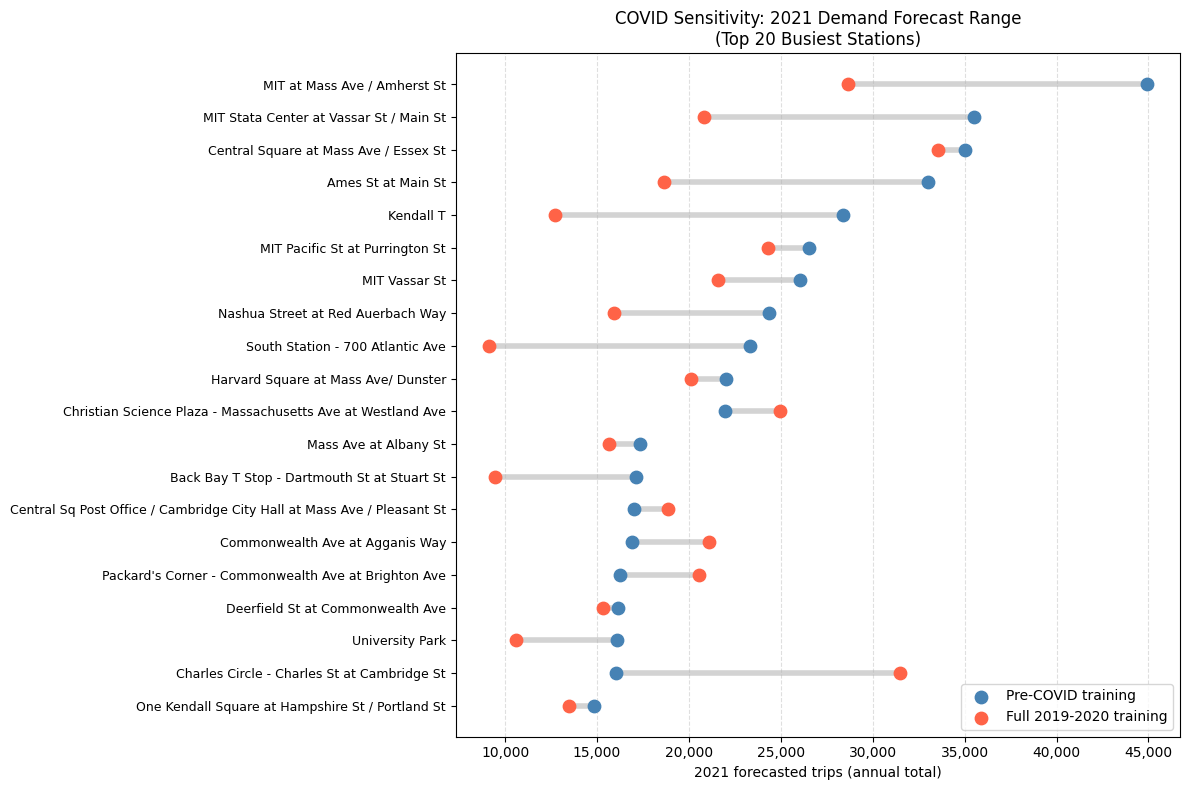

Saved: insight13g_covid_sensitivity.png


In [97]:
# 13i. Visualize the COVID sensitivity range for the top 20 busiest stations

top20 = (
    cmp.assign(busy=cmp['pre_covid_2021_total'])
       .sort_values('busy', ascending=False)
       .head(20)
       .sort_values('pre_covid_2021_total')
)

fig, ax = plt.subplots(figsize=(12, 8))
y = range(len(top20))
lo = top20[['pre_covid_2021_total', 'full_2021_total']].min(axis=1)
hi = top20[['pre_covid_2021_total', 'full_2021_total']].max(axis=1)

ax.hlines(y, lo, hi, color='lightgray', linewidth=4, zorder=1)
ax.scatter(top20['pre_covid_2021_total'], y, color='steelblue',
           s=80, label='Pre-COVID training', zorder=2)
ax.scatter(top20['full_2021_total'], y, color='tomato',
           s=80, label='Full 2019-2020 training', zorder=2)

ax.set_yticks(list(y))
ax.set_yticklabels(top20.index, fontsize=9)
ax.set_xlabel('2021 forecasted trips (annual total)')
ax.set_title('COVID Sensitivity: 2021 Demand Forecast Range\n(Top 20 Busiest Stations)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.legend(loc='lower right')
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig(OUT_DIR + 'insight13g_covid_sensitivity.png', dpi=150)
plt.show()
print("Saved: insight13g_covid_sensitivity.png")


In [98]:
# 13j. Allocate bikes under both training scenarios (full-data vs pre-COVID)
# Wraps the 13d -> 13e -> 13f pipeline into reusable functions so we can call the whole newsvendor allocation once per forecast scenario.
# Note: the per-station-per-month std (s) still comes from the FULL historical record in both scenarios, because one year of pre-COVID monthly data is too few observations for a stable std. 
# Only the forecast mean (m) varies between scenarios.

def build_demand_stats(forecast_df, daily_demand):
    """Mirrors 13d: forecast mean + historical per-station-per-month std."""
    hist_std = (
        daily_demand.groupby(['start station name', 'month'])['daily_trips']
        .std().reset_index()
    )
    hist_std.columns = ['start station name', 'month', 's']
    stats = (
        forecast_df.groupby(['start station name', 'year', 'month'])['forecasted_trips']
        .mean().reset_index()
    )
    stats.columns = ['start station name', 'year', 'month', 'm']
    stats = stats.merge(hist_std, on=['start station name', 'month'], how='left')
    stats['s'] = stats['s'].fillna(0)
    return stats

def run_newsvendor_allocation(forecast_df, daily_demand, total_fleet,
                              critical_ratios=(0.80, 0.85, 0.90, 0.95)):
    """Mirrors 13e + 13f: optimal stock per station, scaled to total fleet."""
    stats = build_demand_stats(forecast_df, daily_demand)
    rows = []
    for cr in critical_ratios:
        for _, r in stats.iterrows():
            m, s = r['m'], r['s']
            if s == 0 or pd.isna(s):
                continue
            opt = max(norm.ppf(cr, loc=m, scale=s), 0)
            rows.append({
                'year': r['year'], 'month': r['month'],
                'station': r['start station name'],
                'm': round(m, 2), 's': round(s, 2),
                'critical_ratio': cr,
                'optimal_stock': round(opt, 2),
            })
    out = pd.DataFrame(rows)
    out['allocated_bikes'] = (
        out.groupby(['year', 'month', 'critical_ratio'])['optimal_stock']
        .transform(lambda x: (x / x.sum()) * total_fleet)
        .round(0).astype(int)
    )
    return out

allocation_full = run_newsvendor_allocation(all_forecasts, daily_demand, total_fleet_capacity)
allocation_pre  = run_newsvendor_allocation(forecasts_pre, daily_demand, total_fleet_capacity)

print(f"Full-data allocation rows: {len(allocation_full):,}")
print(f"Pre-COVID allocation rows: {len(allocation_pre):,}")


Full-data allocation rows: 15,852
Pre-COVID allocation rows: 14,956


In [99]:
# 13k. Compare allocations side by side at CR=0.90, January 2021
# Stations where the two scenarios agree are robust deployments.
# Stations where they diverge are decisions the operator has to make based on their belief about COVID recovery.

CR, MONTH = 0.90, 1

cmp_alloc = (
    allocation_full.query('critical_ratio == @CR and month == @MONTH')
        [['station', 'allocated_bikes']].rename(columns={'allocated_bikes': 'alloc_full'})
    .merge(
        allocation_pre.query('critical_ratio == @CR and month == @MONTH')
            [['station', 'allocated_bikes']].rename(columns={'allocated_bikes': 'alloc_pre'}),
        on='station', how='inner'
    )
)
cmp_alloc['delta_bikes'] = cmp_alloc['alloc_full'] - cmp_alloc['alloc_pre']
cmp_alloc = cmp_alloc.sort_values('delta_bikes')

print(f"Stations OVER-allocated under full-data vs pre-COVID (CR={CR}, month={MONTH}):")
print(cmp_alloc.tail(15).to_string(index=False))

print(f"\nStations UNDER-allocated under full-data vs pre-COVID:")
print(cmp_alloc.head(15).to_string(index=False))

cmp_alloc.to_csv(OUT_DIR + 'covid_allocation_comparison.csv', index=False)
print("\nSaved: covid_allocation_comparison.csv")


Stations OVER-allocated under full-data vs pre-COVID (CR=0.9, month=1):
                                                         station  alloc_full  alloc_pre  delta_bikes
                                              Mass Ave T Station          10          6            4
Harvard University River Houses at DeWolfe St / Cowperthwaite St          12          8            4
                                                Chinatown T Stop          13          9            4
                                      Huntington Ave at Mass Art           9          5            4
                                      Harvard Ave at Brainerd Rd          10          6            4
                                       Longwood Ave at Binney St          15         10            5
                                          Mugar Way at Beacon St          16         11            5
            Lafayette Square at Mass Ave / Main St / Columbia St          13          8            5
                   

In [100]:
# 13k-2. Updated optimal allocation using COVID sensitivity scenarios
# Stations where the two scenarios agree are robust deployments.
# Stations where they diverge are judgment calls dependent on COVID recovery assumptions.

RECOMMENDED_CR = 0.90

def get_allocation(forecast_df, daily_demand, total_fleet_capacity, cr):
    """Run newsvendor allocation for a single recommended CR only."""
    # Build demand stats: forecasted mean + historical std
    hist_std = (
        daily_demand.groupby(['start station name', 'month'])['daily_trips']
        .std().reset_index()
    )
    hist_std.columns = ['start station name', 'month', 's']

    stats = (
        forecast_df.groupby(['start station name', 'year', 'month'])['forecasted_trips']
        .mean().reset_index()
    )
    stats.columns = ['start station name', 'year', 'month', 'm']
    stats = stats.merge(hist_std, on=['start station name', 'month'], how='left')
    stats['s'] = stats['s'].fillna(0)

    # Compute optimal stock at recommended CR only
    rows = []
    for _, r in stats.iterrows():
        m, s = r['m'], r['s']
        if s == 0 or pd.isna(s):
            continue
        opt = max(norm.ppf(cr, loc=m, scale=s), 0)
        rows.append({
            'year': r['year'],
            'month': r['month'],
            'station': r['start station name'],
            'm': round(m, 2),
            's': round(s, 2),
            'critical_ratio': cr,
            'optimal_stock': round(opt, 2),
        })

    out = pd.DataFrame(rows)

    # Scale to fleet size
    out['allocated_bikes'] = (
        out.groupby(['year', 'month'])['optimal_stock']
        .transform(lambda x: (x / x.sum()) * total_fleet_capacity)
        .round(0)
        .astype(int)
    )
    return out

# ── Step 1: Run allocation under both scenarios ──────────────────────────────
allocation_full_cr = get_allocation(all_forecasts, daily_demand, total_fleet_capacity, RECOMMENDED_CR)
allocation_pre_cr  = get_allocation(forecasts_pre, daily_demand, total_fleet_capacity, RECOMMENDED_CR)

print("=" * 60)
print("STEP 1: ALLOCATION UNDER EACH SCENARIO")
print("=" * 60)
print(f"  Full training (2019-2020):       {allocation_full_cr.groupby('month')['allocated_bikes'].sum().mean():.0f} bikes/month")
print(f"  Pre-COVID training (2019-Feb 20): {allocation_pre_cr.groupby('month')['allocated_bikes'].sum().mean():.0f} bikes/month")

# ── Step 2: Merge and compute blended allocation ─────────────────────────────
blended = allocation_full_cr[['year', 'month', 'station', 'm', 's', 'optimal_stock', 'allocated_bikes']].merge(
    allocation_pre_cr[['station', 'month', 'allocated_bikes']].rename(
        columns={'allocated_bikes': 'allocated_bikes_pre'}
    ),
    on=['station', 'month'],
    how='left'
)

blended['allocated_bikes_full'] = blended['allocated_bikes']
blended.drop(columns='allocated_bikes', inplace=True)

# Fill NaN in allocated_bikes_pre with allocated_bikes_full
# WHY: stations that don't appear in the pre-COVID forecast (newer stations with
# insufficient pre-COVID data) fall back to the full-data allocation as the
# best available estimate for those stations
blended['allocated_bikes_pre'] = (
    blended['allocated_bikes_pre']
    .fillna(blended['allocated_bikes_full'])
    .round(0)
    .astype(int)
)

# Blended = average of full and pre-COVID
# WHY: neither scenario is definitively correct — the true 2021 demand likely
# sits between the two depending on speed of COVID recovery
blended['allocated_bikes_blended'] = (
    (blended['allocated_bikes_full'] + blended['allocated_bikes_pre']) / 2
).round(0).astype(int)

# ── Step 3: Flag robust vs sensitive stations ─────────────────────────────────
blended['scenario_delta'] = (
    blended['allocated_bikes_full'] - blended['allocated_bikes_pre']
).abs()

# Threshold set at 75th percentile of scenario deltas — data-driven rather than arbitrary
# Stations above the 75th percentile are meaningfully more sensitive to COVID
# recovery assumptions than the typical station
ROBUST_THRESHOLD = blended['scenario_delta'].quantile(0.75)
blended['robust'] = blended['scenario_delta'] <= ROBUST_THRESHOLD

print("\n" + "=" * 60)
print("STEP 2: SCENARIO DELTA DISTRIBUTION")
print("=" * 60)
print(f"  Robust threshold (75th percentile): {ROBUST_THRESHOLD:.0f} bikes delta")
print(f"  Robust stations (delta <= {ROBUST_THRESHOLD:.0f}):      {blended['robust'].sum():,} / {len(blended):,} station-months")
print(f"  Sensitive stations (delta > {ROBUST_THRESHOLD:.0f}):    {(~blended['robust']).sum():,} / {len(blended):,} station-months")
print(f"\n  Delta distribution:")
print(f"  {'Metric':<10} {'Value':>10}")
print(f"  {'Min':<10} {blended['scenario_delta'].min():>10.0f}")
print(f"  {'Median':<10} {blended['scenario_delta'].median():>10.0f}")
print(f"  {'Mean':<10} {blended['scenario_delta'].mean():>10.2f}")
print(f"  {'75th pct':<10} {ROBUST_THRESHOLD:>10.0f}")
print(f"  {'Max':<10} {blended['scenario_delta'].max():>10.0f}")

# ── Step 4: Sample output ─────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 3A: SAMPLE BLENDED ALLOCATION WITH COMPARISONS PRE AND FULL (January 2021, top 15 by demand)")
print("=" * 60)
sample = (
    blended[blended['month'] == 1]
    .sort_values('m', ascending=False)
    .head(15)
)[['month', 'station', 'allocated_bikes_pre', 'allocated_bikes_full',
   'allocated_bikes_blended', 'scenario_delta', 'robust']]
print(sample.to_string(index=False))


print("\n" + "=" * 60)
print("STEP 3B: SAMPLE BLENDED ALLOCATION (January 2021, top 15 by demand)")
print("=" * 60)
sample = (
    blended[blended['month'] == 1]
    .sort_values('m', ascending=False)
    .head(15)
)[['month', 'station', 'allocated_bikes_blended']]
print(sample.to_string(index=False))


# ── Step 5: Operational guidance ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("STEP 4: OPERATIONAL GUIDANCE")
print("=" * 60)
print(f"""
  Robust threshold: {ROBUST_THRESHOLD:.0f} bikes (75th percentile of scenario deltas)
  WHY THIS THRESHOLD: The delta distribution is heavily concentrated
  at 0-2 bikes (75% of station-months), with a natural drop-off after
  delta=4. Using the 75th percentile is data-driven — stations above
  it are meaningfully more sensitive to COVID recovery assumptions
  than the typical station, not just marginally different.

  Use allocated_bikes_blended as the primary recommendation.

  For ROBUST stations (robust=True, delta <= {ROBUST_THRESHOLD:.0f} bikes):
    - Both scenarios agree within the 75th percentile threshold
    - Deploy with confidence regardless of COVID recovery assumptions
    - No judgment call needed

  For SENSITIVE stations (robust=False, delta > {ROBUST_THRESHOLD:.0f} bikes):
    - Scenarios diverge beyond the typical range — operator judgment required
    - University/office stations: bias toward allocated_bikes_pre
      (expect demand recovery as campuses/offices reopen)
    - Leisure/waterfront stations: bias toward allocated_bikes_full
      (COVID boosted demand may not persist post-recovery)
""")

# ── Export ────────────────────────────────────────────────────────────────────
blended.to_csv(OUT_DIR + 'allocation_covid_sensitivity.csv', index=False)
print("Saved: allocation_covid_sensitivity.csv")

STEP 1: ALLOCATION UNDER EACH SCENARIO
  Full training (2019-2020):       1640 bikes/month
  Pre-COVID training (2019-Feb 20): 1644 bikes/month

STEP 2: SCENARIO DELTA DISTRIBUTION
  Robust threshold (75th percentile): 2 bikes delta
  Robust stations (delta <= 2):      3,004 / 3,963 station-months
  Sensitive stations (delta > 2):    959 / 3,963 station-months

  Delta distribution:
  Metric          Value
  Min                 0
  Median              1
  Mean             1.94
  75th pct            2
  Max                23

STEP 3A: SAMPLE BLENDED ALLOCATION WITH COMPARISONS PRE AND FULL (January 2021, top 15 by demand)
 month                                                                station  allocated_bikes_pre  allocated_bikes_full  allocated_bikes_blended  scenario_delta  robust
     1                                  Central Square at Mass Ave / Essex St                   36                    33                       34               3   False
     1                         

In [101]:
# 13l. *Academic-calendar dampening for university-tagged stations*
# Addresses the feedback that station-level context (academic schedules) should inform the forecast. 
# We derive the dampening factor empirically rather than hardcoding it, then re-run the allocation under dampened forecasts.
# Empirical dampening factor (university low-month / system low-month) < 1.0 means university stations under-perform the system in low months, so we would allocate fewer bikes to them in those months.

ACADEMIC_LOW_MONTHS = [6, 7, 8, 12]   # summer + winter break

# Step 1: derive the empirical dampening factor from history
uni_stations = df.loc[df['station_type'] == 'university', 'start station name'].unique()
uni_mask     = df['start station name'].isin(uni_stations)

uni_low_share = df.loc[uni_mask & df['month'].isin(ACADEMIC_LOW_MONTHS)].shape[0] / df.loc[uni_mask].shape[0]
sys_low_share = df.loc[df['month'].isin(ACADEMIC_LOW_MONTHS)].shape[0] / df.shape[0]

DAMPEN = uni_low_share / sys_low_share
print(f"University-tagged stations: {len(uni_stations)}")
print(f"University share of trips in low-academic months: {uni_low_share:.3f}")
print(f"System-wide share of trips in low-academic months:  {sys_low_share:.3f}")
print(f"Empirical dampening factor (university low-month / system low-month): {DAMPEN:.3f}")
print(f"Interpretation: a value < 1.0 means university stations under-perform the system in low months")

# Step 2: apply dampening to a forecast DataFrame (mean only — std is held fixed)
def apply_academic_dampening(forecast_df,
                              factor=DAMPEN,
                              stations=uni_stations,
                              low_months=ACADEMIC_LOW_MONTHS):
    out = forecast_df.copy()
    m = out['start station name'].isin(stations) & out['month'].isin(low_months)
    out.loc[m, 'forecasted_trips'] *= factor
    return out

all_forecasts_d = apply_academic_dampening(all_forecasts)
forecasts_pre_d = apply_academic_dampening(forecasts_pre)

# Step 3: re-run the allocation under dampened forecasts (reuses 13j function)
allocation_full_d = run_newsvendor_allocation(all_forecasts_d, daily_demand, total_fleet_capacity)
allocation_pre_d  = run_newsvendor_allocation(forecasts_pre_d, daily_demand, total_fleet_capacity)

# Step 4: show what changed for university stations at CR=0.90, July (peak break month)
CR, MONTH = 0.90, 7
before = (
    allocation_full.query('critical_ratio == @CR and month == @MONTH and station in @uni_stations')
        [['station', 'allocated_bikes']].rename(columns={'allocated_bikes': 'before_dampening'})
)
after = (
    allocation_full_d.query('critical_ratio == @CR and month == @MONTH and station in @uni_stations')
        [['station', 'allocated_bikes']].rename(columns={'allocated_bikes': 'after_dampening'})
)
uni_compare = before.merge(after, on='station')
uni_compare['delta'] = uni_compare['after_dampening'] - uni_compare['before_dampening']
uni_compare = uni_compare.sort_values('delta')

print(f"\nUniversity-station allocation changes (CR={CR}, month={MONTH}):")
print(uni_compare.to_string(index=False))

uni_compare.to_csv(OUT_DIR + 'academic_dampening_effect.csv', index=False)
print("\nSaved: academic_dampening_effect.csv")


University-tagged stations: 25
University share of trips in low-academic months: 0.347
System-wide share of trips in low-academic months:  0.389
Empirical dampening factor (university low-month / system low-month): 0.890
Interpretation: a value < 1.0 means university stations under-perform the system in low months

University-station allocation changes (CR=0.9, month=7):
                                                           station  before_dampening  after_dampening  delta
                       Northeastern University - North Parking Lot                20               18     -2
                                      MIT at Mass Ave / Amherst St                25               23     -2
                                                     MIT Vassar St                19               17     -2
                           MIT Stata Center at Vassar St / Main St                19               17     -2
                               Harvard Square at Mass Ave/ Dunster               